<a href="https://colab.research.google.com/github/EA88837/Siamese-Networks-for-Image-Similarity-Task/blob/main/pgmprojectMINST%23%2312.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import cv2

# Install pgmpy library if not already installed
!pip install pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination, BeliefPropagation
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

# Set Seaborn style and palette for attractive plots
sns.set_style("whitegrid")
sns.set_palette("viridis")

In [ ]:
# --- 2. Discretization (Modified for 5 bins) ---

# Function to discretize a continuous feature value into one of 5 bins
def discretize_feature(value, feature_name, quantiles_df):
    # Using 5 bins: 'very_low', 'low', 'medium', 'high', 'very_high'
    q20 = quantiles_df.loc[0.20, feature_name]
    q40 = quantiles_df.loc[0.40, feature_name]
    q60 = quantiles_df.loc[0.60, feature_name]
    q80 = quantiles_df.loc[0.80, feature_name]

    if value <= q20:
        return 'very_low'
    elif value <= q40:
        return 'low'
    elif value <= q60:
        return 'medium'
    elif value <= q80:
        return 'high'
    else:
        return 'very_high'

# Calculate quintiles (20th, 40th, 60th, 80th percentiles) for each raw feature
quantiles_df = raw_features_df.quantile([0.20, 0.40, 0.60, 0.80])

# Apply discretization to all raw features
discrete_features = raw_features_df.copy()
for col in raw_features_df.columns:
    discrete_features[col] = raw_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_df))
discrete_features_df = discrete_features

In [ ]:
# --- 3. Combine Discretized Features and Labels (Re-run from 0eca586b) ---

# Create a DataFrame for the digit labels
labels_df = pd.DataFrame(y_test_subset, columns=['digit_label'])
# Concatenate discrete features and digit labels into a single DataFrame for PGM
pgm_data_df = pd.concat([discrete_features_df, labels_df], axis=1)

In [ ]:
# --- 4. Build Bayesian Network Structure (Re-run from 89a4152b) ---

# Define the structure of the Bayesian Network: digit_label influences all four quadrants
bn_model = DiscreteBayesianNetwork([
    ('digit_label', 'TL'), # digit_label influences Top-Left quadrant
    ('digit_label', 'TR'), # digit_label influences Top-Right quadrant
    ('digit_label', 'BL'), # digit_label influences Bottom-Left quadrant
    ('digit_label', 'BR')  # digit_label influences Bottom-Right quadrant
])

In [ ]:
# --- 5. Define Conditional Probability Distributions (CPDs) (Modified for 5 bins) ---

quadrant_cardinality = 5 # Number of bins for discretized quadrant features
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label
digit_counts = pgm_data_df['digit_label'].value_counts().sort_index()
digit_probabilities = digit_counts.values / len(pgm_data_df)
digit_probabilities_2d = digit_probabilities.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_2d
)

cpd_quadrants = []
category_map = {cat: i for i, cat in enumerate(quadrant_categories)} # Map category names to numerical indices

# Create CPDs for each quadrant feature given the digit_label
for quadrant_feature in ['TL', 'TR', 'BL', 'BR']:
    values = np.zeros((quadrant_cardinality, digit_label_cardinality))

    for digit in range(digit_label_cardinality):
        digit_data = pgm_data_df[pgm_data_df['digit_label'] == digit] # Filter data for the current digit
        if not digit_data.empty:
            quadrant_counts = digit_data[quadrant_feature].value_counts() # Count occurrences of each quadrant category for the digit
            for category, count in quadrant_counts.items():
                if category in category_map:
                    values[category_map[category], digit] = count / len(digit_data) # Calculate conditional probability
            col_sum = np.sum(values[:, digit])
            # Ensure probabilities sum to 1 for each digit column (marginalizing over quadrant categories)
            if col_sum > 0:
                values[:, digit] /= col_sum

    cpd = TabularCPD(
        variable=quadrant_feature,
        variable_card=quadrant_cardinality,
        values=values,
        evidence=['digit_label'],
        evidence_card=[digit_label_cardinality],
        state_names={
            quadrant_feature: quadrant_categories, # Assign human-readable state names for quadrants
            'digit_label': list(range(digit_label_cardinality))
        }
    )
    cpd_quadrants.append(cpd)
bn_model.add_cpds(cpd_digit_label, *cpd_quadrants) # Add all CPDs to the Bayesian Network model

# Check if the model is consistent after adding all CPDs
print("\nModel is consistent after adding all CPDs:", bn_model.check_model())


Model is consistent after adding all CPDs: True


In [ ]:
# --- 6. Perform Inference (Re-run with new CPDs) ---

# Initialize the VariableElimination inference algorithm for the Bayesian Network
infer = VariableElimination(bn_model)

# Select a test image that was not part of the PGM training data to avoid data leakage
all_test_indices = set(range(len(x_test)))
pgm_train_indices = set(sample_indices)
available_test_indices = list(all_test_indices - pgm_train_indices)

if not available_test_indices:
    test_img_idx = np.random.choice(len(x_test))
else:
    test_img_idx = np.random.choice(available_test_indices)

query_image_pgm = x_test[test_img_idx]
true_label_pgm = y_test[test_img_idx]
raw_features_pgm = extract_quadrant_features(query_image_pgm.squeeze())

# Discretize the raw quadrant features of the selected test image
discrete_features_pgm = {}
for feature_name, value in raw_features_pgm.items():
    discrete_features_pgm[feature_name] = discretize_feature(value, feature_name, quantiles_df)

# Perform inference to predict the digit label based on the discretized features
query_result = infer.query(variables=['digit_label'], evidence=discrete_features_pgm)
predicted_label_pgm = query_result.values.argmax() # Get the label with the highest probability

print(f"\nSelected test image index: {test_img_idx}")
print(f"True Label: {true_label_pgm}")
print(f"Raw Quadrant Features: {raw_features_pgm}")
print(f"Discretized Quadrant Features: {discrete_features_pgm}")
print(f"Predicted Label: {predicted_label_pgm}")
print("\nProbability distribution over digit_label:")
print(query_result)


Selected test image index: 1950
True Label: 7
Raw Quadrant Features: {'TL': np.float32(0.101700686), 'TR': np.float32(0.10572229), 'BL': np.float32(0.0232493), 'BR': np.float32(0.12773108)}
Discretized Quadrant Features: {'TL': 'medium', 'TR': 'low', 'BL': 'very_low', 'BR': 'low'}
Predicted Label: 7

Probability distribution over digit_label:
+----------------+--------------------+
| digit_label    |   phi(digit_label) |
+================+====================+
| digit_label(0) |             0.0000 |
+----------------+--------------------+
| digit_label(1) |             0.0517 |
+----------------+--------------------+
| digit_label(2) |             0.0123 |
+----------------+--------------------+
| digit_label(3) |             0.0497 |
+----------------+--------------------+
| digit_label(4) |             0.2363 |
+----------------+--------------------+
| digit_label(5) |             0.0410 |
+----------------+--------------------+
| digit_label(6) |             0.0027 |
+-------------

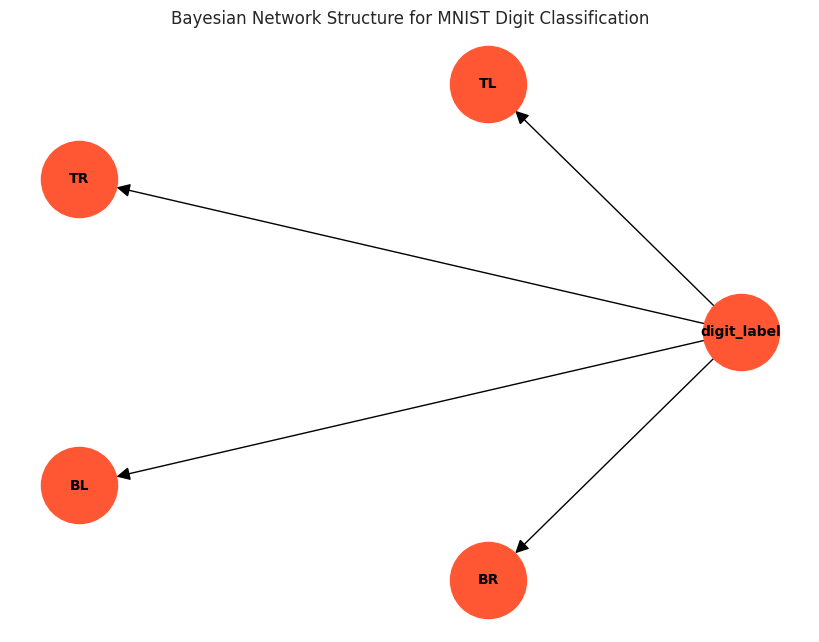

In [ ]:
# --- 7. Bayesian Network Structure Visualization ---

plt.figure(figsize=(8, 6)) # Create a figure for the plot
pos = nx.circular_layout(bn_model) # Arrange nodes in a circular layout
nx.draw(bn_model, pos=pos, with_labels=True, node_size=3000, node_color='#FF5733', font_size=10, font_weight='bold', arrowsize=20) # Draw the Bayesian Network graph
plt.title("Bayesian Network Structure for MNIST Digit Classification") # Set the title of the plot
plt.show() # Display the plot

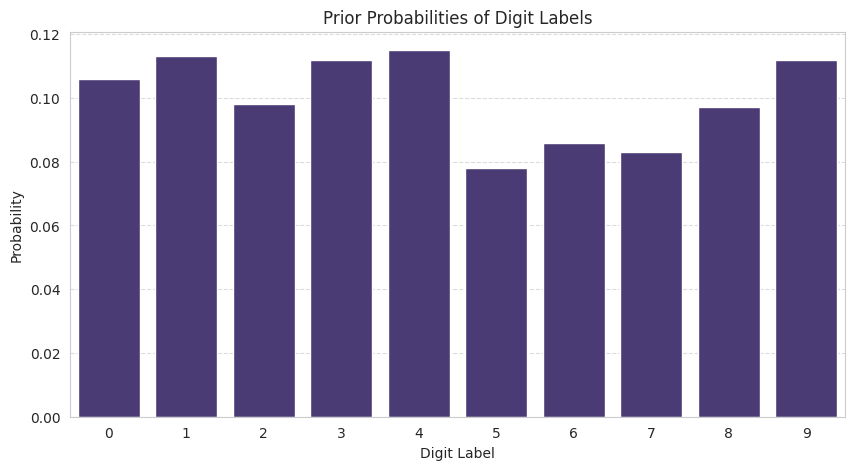

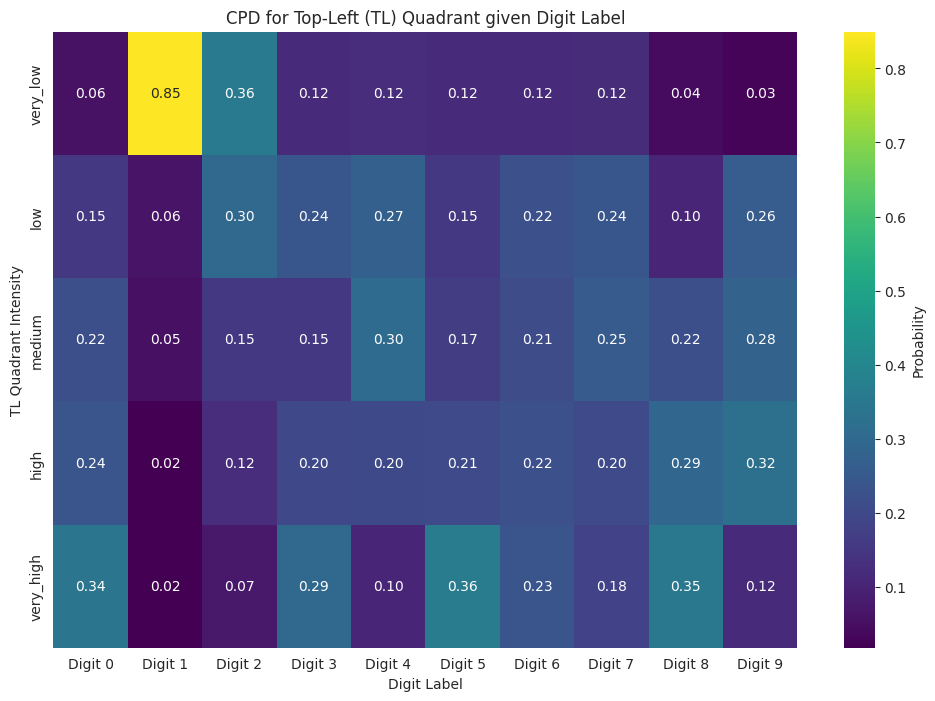

In [ ]:
# --- 8. Conditional Probability Distribution (CPD) Visualizations ---

# Visualize CPD for digit_label (prior probabilities)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(range(digit_label_cardinality)), y=cpd_digit_label.values.flatten()) # Create a bar plot of prior probabilities
plt.title("Prior Probabilities of Digit Labels") # Set plot title
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("Probability") # Set y-axis label
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
plt.show() # Display the plot

# Visualize CPD for TL given digit_label as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    cpd_quadrants[0].values, # Assuming cpd_quadrants[0] is for 'TL' (Top-Left quadrant)
    xticklabels=[f'Digit {i}' for i in range(digit_label_cardinality)], # X-axis labels for digit classes
    yticklabels=quadrant_categories, # Y-axis labels for quadrant categories
    annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Probability'} # Add annotations, format, colormap, and colorbar label
)
plt.title("CPD for Top-Left (TL) Quadrant given Digit Label") # Set plot title
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("TL Quadrant Intensity") # Set y-axis label
plt.show() # Display the plot

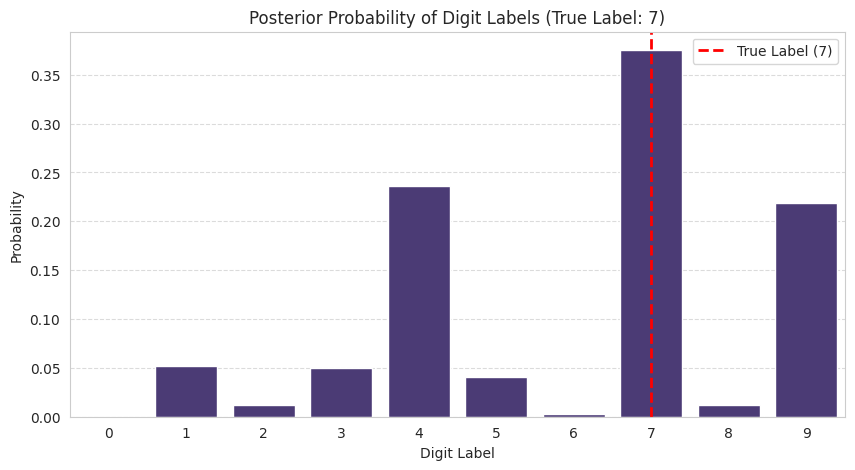

In [ ]:
# --- 9. Inference Result Visualization ---

plt.figure(figsize=(10, 5)) # Create a figure for the plot
sns.barplot(x=list(range(digit_label_cardinality)), y=query_result.values.flatten()) # Create a bar plot of posterior probabilities
plt.title(f"Posterior Probability of Digit Labels (True Label: {true_label_pgm})") # Set plot title including true label
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("Probability") # Set y-axis label
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid

plt.axvline(x=true_label_pgm, color='red', linestyle='--', linewidth=2, label=f'True Label ({true_label_pgm})') # Add a vertical line for the true label
plt.legend() # Display the legend
plt.show() # Display the plot

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate predictions for the test subset
pgm_predictions = []
pgm_true_labels = []

# We will use the x_test_subset and y_test_subset that were already created for PGM training.
# If you wish to use a completely separate test set, you would need to load and preprocess it here.

print("Generating PGM predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract and discretize features for the current image
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference using Variable Elimination to get predicted label
    query_result_subset = infer.query(variables=['digit_label'], evidence=current_discrete_features)
    predicted_label = query_result_subset.values.argmax()

    pgm_predictions.append(predicted_label)
    pgm_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix...")

# Calculate the confusion matrix
cm = confusion_matrix(pgm_true_labels, pgm_predictions, labels=range(digit_label_cardinality))

# Print classification report for more detailed metrics (optional)
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(pgm_true_labels, pgm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("Confusion Matrix:")
print(cm)

Generating PGM predictions for the test subset...
Predictions generated. Calculating confusion matrix...

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46       106
           1       0.55      0.81      0.65       113
           2       0.38      0.34      0.36        98
           3       0.33      0.16      0.22       112
           4       0.28      0.34      0.31       115
           5       0.25      0.05      0.09        78
           6       0.55      0.31      0.40        86
           7       0.31      0.19      0.24        83
           8       0.36      0.22      0.27        97
           9       0.28      0.45      0.34       112

    accuracy                           0.37      1000
   macro avg       0.36      0.35      0.33      1000
weighted avg       0.36      0.37      0.34      1000

Confusion Matrix:
[[71  6  8  1  5  3  1  0  2  9]
 [ 0 91  7  1 11  2  0  0  0  1]
 [23 16 33  0 12  0  2  2  3

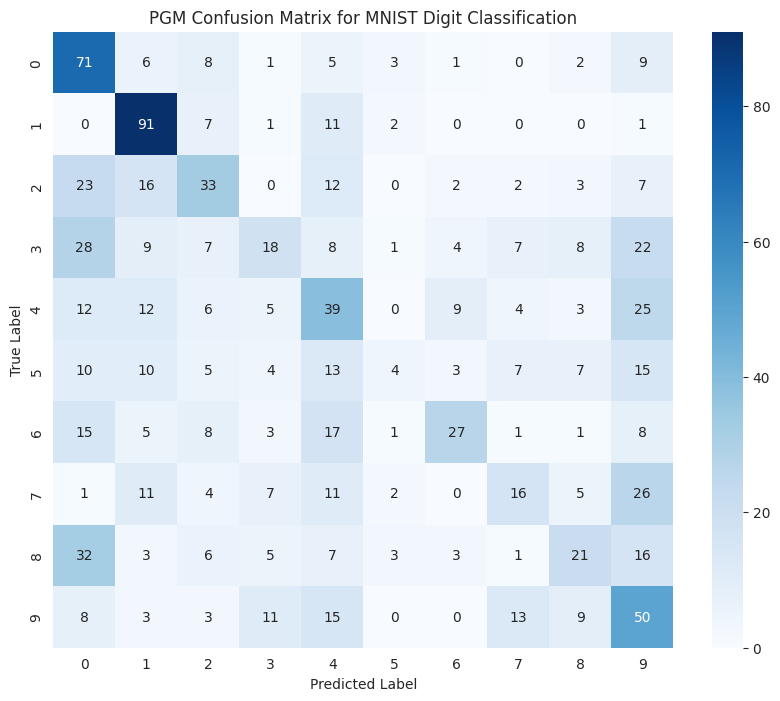

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PGM Confusion Matrix for MNIST Digit Classification')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# Re-generate predictions to get probabilities for each class (needed for ROC curve)
pgm_pred_probs = []

print("Generating PGM prediction probabilities for ROC analysis...")
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference to get probability distribution over digit_label
    query_result_subset = infer.query(variables=['digit_label'], evidence=current_discrete_features)
    pgm_pred_probs.append(query_result_subset.values.flatten())

pgm_pred_probs = np.array(pgm_pred_probs)

# Binarize the true labels for one-vs-rest ROC calculation
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(pgm_true_labels)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# Get a distinct color palette for the ROC curves
colors = sns.color_palette('tab10', digit_label_cardinality) # Changed palette to 'tab10'

for i in range(digit_label_cardinality):
    # Ensure we have probabilities for the current class
    if pgm_pred_probs.shape[1] > i:
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], pgm_pred_probs[:, i]) # Calculate FPR, TPR
        roc_auc[i] = auc(fpr[i], tpr[i]) # Calculate AUC


print("AUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc:
        print(f"Class {i}: {roc_auc[i]:.2f}")

Generating PGM prediction probabilities for ROC analysis...
AUC for each class:
Class 0: 0.83
Class 1: 0.94
Class 2: 0.79
Class 3: 0.70
Class 4: 0.73
Class 5: 0.71
Class 6: 0.86
Class 7: 0.79
Class 8: 0.76
Class 9: 0.78


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Prepare data for Logistic Regression using the same features and labels as PGM
# We'll use the raw_features_df (X) and y_test_subset (y) (our sampled data)

X = raw_features_df.values # Features (raw quadrant mean intensities)
y = y_test_subset # Labels (true digit labels)

# For simplicity and direct comparison with PGM on the same subset, we'll train on the full subset
# In a real scenario, you'd split this into train/validation/test sets.

print(f"Shape of features for LR: {X.shape}")
print(f"Shape of labels for LR: {y.shape}")

Shape of features for LR: (1000, 4)
Shape of labels for LR: (1000,)


In [ ]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Logistic Regression: X_train_lr shape: {X_train_lr.shape}, X_test_lr shape: {X_test_lr.shape}")
print(f"SVM: X_train_svm shape: {X_train_svm.shape}, X_test_svm shape: {X_test_svm.shape}")
print(f"Neural Network: X_train_nn shape: {X_train_nn.shape}, X_test_nn shape: {X_test_nn.shape}")

Logistic Regression: X_train_lr shape: (700, 4), X_test_lr shape: (300, 4)
SVM: X_train_svm shape: (700, 4), X_test_svm shape: (300, 4)
Neural Network: X_train_nn shape: (700, 4), X_test_nn shape: (300, 4)


In [ ]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', multi_class='multinomial') # Initialize Logistic Regression model

log_reg_model.fit(X_train_lr, y_train_lr) # Train the Logistic Regression model on the training data

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.78      0.43        32
           1       0.37      0.97      0.54        34
           2       1.00      0.10      0.19        29
           3       0.23      0.21      0.22        34
           4       0.21      0.50      0.30        34
           5       0.00      0.00      0.00        23
           6       0.00      0.00      0.00        26
           7       0.00      0.00      0.00        25
           8       0.00      0.00      0.00        29
           9       0.15      0.06      0.09        34

    accuracy                           0.29       300
   macro avg       0.23      0.26      0.18       300
weighted avg       0.24      0.29      0.19       300


Logistic Regression Confusion Matrix:
[[25  5  0  1  1  0  0  0  0  0]
 [ 0 33  0  0  1  0  0  0  0  0]
 [12  6  3  0  8  0  0  0  0  0]
 [15  5  0  7  6  0  0  0  0  1]
 [ 3 10  0  3 17  0  0  0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


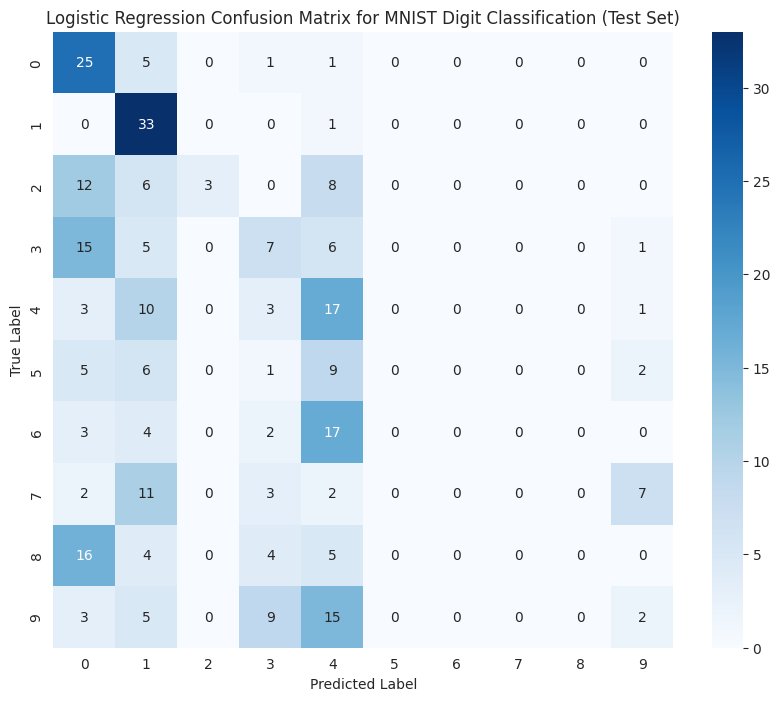

In [ ]:
log_reg_predictions = log_reg_model.predict(X_test_lr)
log_reg_pred_probs = log_reg_model.predict_proba(X_test_lr)

# Print Classification Report for Logistic Regression
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test_lr, log_reg_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for Logistic Regression
log_reg_cm = confusion_matrix(y_test_lr, log_reg_predictions, labels=range(digit_label_cardinality))
print("\nLogistic Regression Confusion Matrix:")
print(log_reg_cm)

# Visualize the Confusion Matrix for Logistic Regression
plt.figure(figsize=(10, 8))
sns.heatmap(log_reg_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix for MNIST Digit Classification (Test Set)')
plt.show()

In [ ]:
from pgmpy.inference import BeliefPropagation

# Initialize Belief Propagation inference object for the Bayesian Network
infer_bp = BeliefPropagation(bn_model)

print("Generating PGM predictions using Belief Propagation for the test subset...")
pgm_predictions_bp = []
pgm_pred_probs_bp = []

# Iterate through the test subset to make predictions using Belief Propagation
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference using Belief Propagation to get predicted label and probabilities
    query_result_bp = infer_bp.query(variables=['digit_label'], evidence=current_discrete_features, show_progress=False)
    predicted_label_bp = query_result_bp.values.argmax()

    pgm_predictions_bp.append(predicted_label_bp)
    pgm_pred_probs_bp.append(query_result_bp.values.flatten())

pgm_pred_probs_bp = np.array(pgm_pred_probs_bp)

print("Predictions generated with Belief Propagation. Calculating metrics...")

# Print Classification Report for PGM (Belief Propagation)
print("\nPGM (Belief Propagation) Classification Report:")
print(classification_report(y_test_subset, pgm_predictions_bp, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for PGM (Belief Propagation)
pgm_cm_bp = confusion_matrix(y_test_subset, pgm_predictions_bp, labels=range(digit_label_cardinality))
print("\nPGM (Belief Propagation) Confusion Matrix:")
print(pgm_cm_bp)

# Removed heatmap visualization for PGM (Belief Propagation) as per user request.

# Calculate and plot ROC AUC for PGM (Belief Propagation - One-vs-Rest)
y_true_binarized = label_binarizer.fit_transform(y_test_subset)

fpr_bp = dict()
tpr_bp = dict()
roc_auc_bp = dict()

# Get a distinct color palette for the ROC curves
colors_bp = sns.color_palette('Paired', digit_label_cardinality) # Changed palette to 'Paired'

for i in range(digit_label_cardinality):
    if pgm_pred_probs_bp.shape[1] > i:
        fpr_bp[i], tpr_bp[i], _ = roc_curve(y_true_binarized[:, i], pgm_pred_probs_bp[:, i]) # Calculate FPR, TPR
        roc_auc_bp[i] = auc(fpr_bp[i], tpr_bp[i]) # Calculate AUC


print("\nAUC for each class (PGM - Belief Propagation):")
for i in range(digit_label_cardinality):
    if i in roc_auc_bp:
        print(f"Class {i}: {roc_auc_bp[i]:.2f}")

Generating PGM predictions using Belief Propagation for the test subset...
Predictions generated with Belief Propagation. Calculating metrics...

PGM (Belief Propagation) Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46       106
           1       0.55      0.81      0.65       113
           2       0.38      0.34      0.36        98
           3       0.33      0.16      0.22       112
           4       0.28      0.34      0.31       115
           5       0.25      0.05      0.09        78
           6       0.55      0.31      0.40        86
           7       0.31      0.19      0.24        83
           8       0.36      0.22      0.27        97
           9       0.28      0.45      0.34       112

    accuracy                           0.37      1000
   macro avg       0.36      0.35      0.33      1000
weighted avg       0.36      0.37      0.34      1000


PGM (Belief Propagation) Confusion Matrix:
[[7

### PGM (Belief Propagation) Confusion Matrix Heatmap

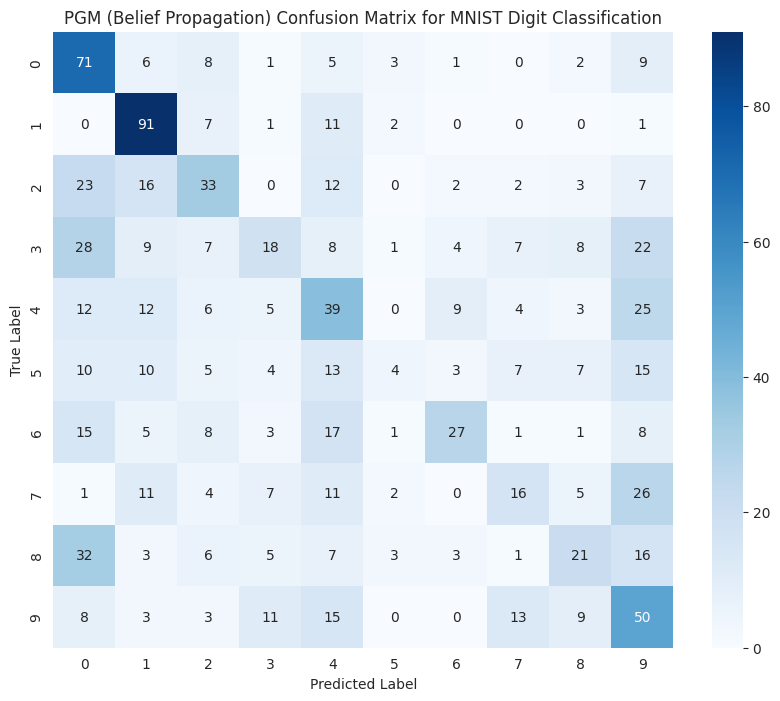

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(pgm_cm_bp, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PGM (Belief Propagation) Confusion Matrix for MNIST Digit Classification')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


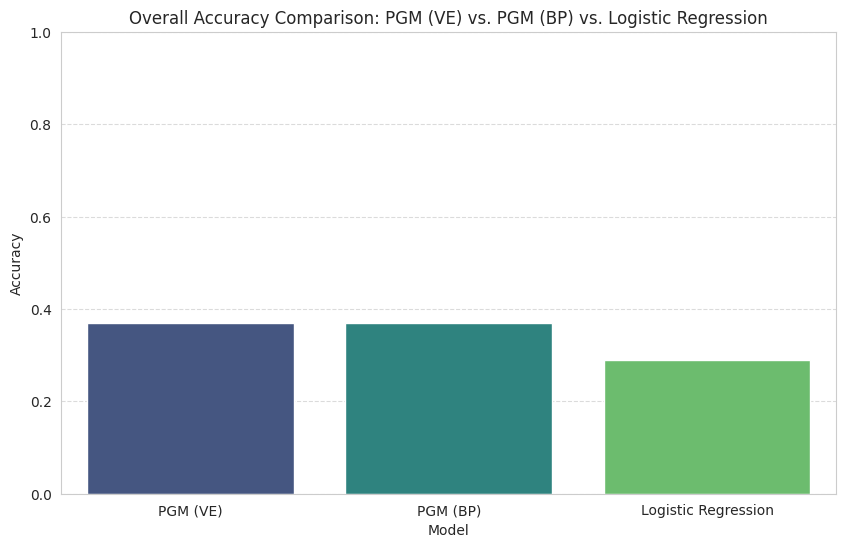

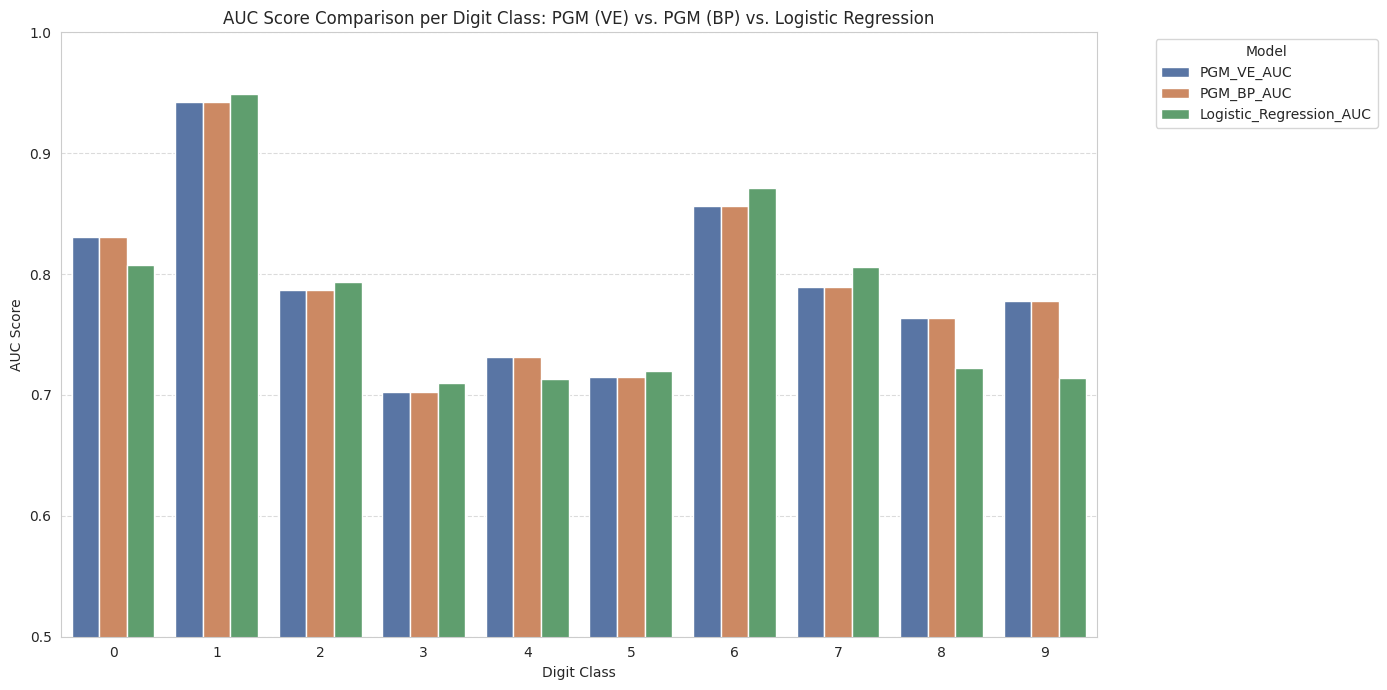

In [ ]:
# Get accuracy from Classification Report for PGM (Variable Elimination)
from sklearn.metrics import classification_report
pgm_accuracy_report = classification_report(pgm_true_labels, pgm_predictions, output_dict=True)
pgm_accuracy = float(pgm_accuracy_report['accuracy'])

# Get accuracy from Classification Report for PGM (Belief Propagation)
pgm_bp_accuracy_report = classification_report(y_test_subset, pgm_predictions_bp, output_dict=True)
pgm_bp_accuracy = float(pgm_bp_accuracy_report['accuracy'])

# Get accuracy from Classification Report for Logistic Regression
log_reg_accuracy_report = classification_report(y_test_lr, log_reg_predictions, output_dict=True)
log_reg_accuracy = float(log_reg_accuracy_report['accuracy'])

# Create an updated DataFrame for overall accuracy comparison
accuracy_df_updated = pd.DataFrame({
    'Model': ['PGM (VE)', 'PGM (BP)', 'Logistic Regression'],
    'Accuracy': [pgm_accuracy, pgm_bp_accuracy, log_reg_accuracy]
})

# Plot overall accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=accuracy_df_updated, palette='viridis', legend=False)
plt.title('Overall Accuracy Comparison: PGM (VE) vs. PGM (BP) vs. Logistic Regression')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Adjust y-limit to better show differences, max accuracy is 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Extract AUCs from previous outputs
# PGM AUCs (from 'roc_auc' dictionary for Variable Elimination)
pgm_auc = [
    roc_auc[i] for i in range(digit_label_cardinality)
]

# PGM AUCs (from 'roc_auc_bp' dictionary for Belief Propagation)
pgm_auc_bp = [
    roc_auc_bp[i] for i in range(digit_label_cardinality)
]

# Logistic Regression AUCs (from 'roc_auc_lr' dictionary)
log_reg_auc = [
    roc_auc_lr[i] for i in range(digit_label_cardinality)
]

# Create an updated DataFrame for AUC comparison per digit class
auc_comparison_df_updated = pd.DataFrame({
    'Digit Class': list(range(digit_label_cardinality)),
    'PGM_VE_AUC': pgm_auc, # Original PGM (Variable Elimination) AUC
    'PGM_BP_AUC': pgm_auc_bp, # PGM (Belief Propagation) AUC
    'Logistic_Regression_AUC': log_reg_auc
})

# Melt the DataFrame for easier plotting with Seaborn
auc_melted_df_updated = auc_comparison_df_updated.melt(id_vars='Digit Class', var_name='Model', value_name='AUC')

# Plot AUC comparison per digit class
plt.figure(figsize=(14, 7))
sns.barplot(x='Digit Class', y='AUC', hue='Model', data=auc_melted_df_updated, palette='deep')
plt.title('AUC Score Comparison per Digit Class: PGM (VE) vs. PGM (BP) vs. Logistic Regression')
plt.ylabel('AUC Score')
plt.xlabel('Digit Class')
plt.ylim(0.5, 1) # AUC scores typically range from 0.5 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Encode target labels to numerical values (0-9) for the full dataset first
encoder = LabelEncoder()
y_encoded_full = encoder.fit_transform(y)

# Convert integer labels to one-hot encoded vectors for Neural Network training
# Apply encoding to the training labels (y_train_nn) for the model training
y_train_nn_one_hot = to_categorical(y_train_nn, num_classes=digit_label_cardinality)
y_test_nn_one_hot = to_categorical(y_test_nn, num_classes=digit_label_cardinality)

# Define the Neural Network model architecture
# Given 4 input features (quadrants) and 10 output classes (digits)
model_nn = Sequential([
    Input(shape=(X_train_nn.shape[1],)), # Use Input layer to specify input shape
    Dense(64, activation='relu'), # Input layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'), # Hidden layer with 32 neurons and ReLU activation
    Dense(digit_label_cardinality, activation='softmax') # Output layer with 10 neurons (for 10 classes) and Softmax activation for probabilities
])

# Compile the model with Adam optimizer, categorical crossentropy loss, and accuracy metric
model_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network model on the training data
# Using a small number of epochs for quick demonstration
history = model_nn.fit(X_train_nn, y_train_nn_one_hot, epochs=20, batch_size=32, verbose=0)

print("Simple Neural Network model trained successfully.")

Simple Neural Network model trained successfully.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Make predictions on the test set
nn_predictions = model_nn.predict(X_test_nn).argmax(axis=1)
nn_pred_probs = model_nn.predict(X_test_nn)

# Print Classification Report for Neural Network
print("\nSimple Neural Network Classification Report:")
print(classification_report(y_test_nn, nn_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for Neural Network
nn_cm = confusion_matrix(y_test_nn, nn_predictions, labels=range(digit_label_cardinality))
print("\nSimple Neural Network Confusion Matrix:")
print(nn_cm)

# Removed heatmap visualization for Simple Neural Network as per user request.

# Compute ROC curve and ROC area for each class (one-vs-rest)
label_binarizer_nn = LabelBinarizer()
y_test_nn_binarized = label_binarizer_nn.fit_transform(y_test_nn)

fpr_nn = dict()
tpr_nn = dict()
roc_auc_nn = dict()

for i in range(digit_label_cardinality):
    if nn_pred_probs.shape[1] > i:
        fpr_nn[i], tpr_nn[i], _ = roc_curve(y_test_nn_binarized[:, i], nn_pred_probs[:, i])
        roc_auc_nn[i] = auc(fpr_nn[i], tpr_nn[i])

print("\nAUC for each class (Neural Network):")
for i in range(digit_label_cardinality):
    if i in roc_auc_nn:
        print(f"Class {i}: {roc_auc_nn[i]:.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Simple Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.78      0.49        32
           1       0.60      0.91      0.72        34
           2       0.53      0.34      0.42        29
           3       0.19      0.15      0.17        34
           4       0.23      0.44      0.30        34
           5       0.00      0.00      0.00        23
           6       0.41      0.27      0.33        26
           7       0.62      0.32      0.42        25
           8       0.20      0.07      0.10        29
           9       0.22      0.18      0.20        34

    accuracy                           0.36       300
   macro avg       0.33      0.35      0.31       300
weighted avg       0.34      0.36      0.32       300


Simple Neural Network Confusion Matrix:
[[25  2  1  3  0  0  0  0  0  1]
 [ 0 31  0  0  1  0  0  2  0  0]
 [ 8  1 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def extract_16_region_features(image):
    h, w = image.shape[0], image.shape[1]
    # Calculate dimensions for each sub-region (4x4 grid)
    h_region, w_region = h // 4, w // 4
    features = {}
    region_idx = 1
    for i in range(4):
        for j in range(4):
            # Extract the current region
            region = image[i*h_region:(i+1)*h_region, j*w_region:(j+1)*w_region]
            # Calculate mean intensity for the region
            features[f'R{i+1}C{j+1}'] = np.mean(region)
            region_idx += 1
    return features

# Extract 16-region features for each image in the subset
raw_features_16_regions = []
for img in x_test_subset:
    raw_features_16_regions.append(extract_16_region_features(img.squeeze()))
raw_features_16_regions_df = pd.DataFrame(raw_features_16_regions)

print("DataFrame of 16-region features created successfully. Displaying first 5 rows:")
print(raw_features_16_regions_df.head())

DataFrame of 16-region features created successfully. Displaying first 5 rows:
       R1C1      R1C2      R1C3  R1C4      R2C1      R2C2      R2C3      R2C4  \
0  0.000000  0.079392  0.163745   0.0  0.000000  0.363986  0.159584  0.001441   
1  0.000000  0.066026  0.203521   0.0  0.000000  0.046819  0.233373  0.000000   
2  0.040096  0.312765  0.201280   0.0  0.006242  0.276431  0.480592  0.013125   
3  0.000000  0.000000  0.000000   0.0  0.105642  0.190556  0.287395  0.000000   
4  0.000000  0.022009  0.000240   0.0  0.097479  0.385034  0.398159  0.000000   

   R3C1      R3C2      R3C3      R3C4  R4C1      R4C2      R4C3      R4C4  
0   0.0  0.448339  0.713165  0.008964   0.0  0.006002  0.047699  0.000000  
1   0.0  0.350060  0.418007  0.000000   0.0  0.226971  0.002081  0.000000  
2   0.0  0.146859  0.400160  0.090036   0.0  0.260424  0.307803  0.018407  
3   0.0  0.103721  0.498119  0.041777   0.0  0.000000  0.125730  0.000000  
4   0.0  0.167267  0.583433  0.148940   0.0  0.000000 

In [ ]:
quantiles_16_regions_df = raw_features_16_regions_df.quantile([0.20, 0.40, 0.60, 0.80])

discrete_features_16_regions = raw_features_16_regions_df.copy()
for col in raw_features_16_regions_df.columns:
    discrete_features_16_regions[col] = raw_features_16_regions_df[col].apply(lambda x: discretize_feature(x, col, quantiles_16_regions_df))
discrete_features_16_regions_df = discrete_features_16_regions

print("DataFrame of discretized 16-region features created successfully. Displaying first 5 rows:")
print(discrete_features_16_regions_df.head())

DataFrame of discretized 16-region features created successfully. Displaying first 5 rows:
        R1C1       R1C2      R1C3      R1C4       R2C1      R2C2      R2C3  \
0   very_low       high      high  very_low   very_low    medium  very_low   
1   very_low       high      high  very_low   very_low  very_low  very_low   
2  very_high  very_high      high  very_low       high       low      high   
3   very_low   very_low  very_low  very_low  very_high       low       low   
4   very_low     medium  very_low  very_low  very_high      high    medium   

       R2C4      R3C1      R3C2       R3C3       R3C4      R4C1      R4C2  \
0    medium  very_low      high  very_high       high  very_low  very_low   
1  very_low  very_low    medium     medium   very_low  very_low      high   
2      high  very_low       low     medium  very_high  very_low      high   
3  very_low  very_low  very_low       high       high  very_low  very_low   
4  very_low  very_low       low  very_high  very_high  

In [ ]:
labels_df_16_regions = pd.DataFrame(y_test_subset, columns=['digit_label'])
pgm_data_16_regions_df = pd.concat([discrete_features_16_regions_df, labels_df_16_regions], axis=1)

print("DataFrame with 16-region discretized features and digit labels created successfully. Displaying first 5 rows:")
print(pgm_data_16_regions_df.head())

DataFrame with 16-region discretized features and digit labels created successfully. Displaying first 5 rows:
        R1C1       R1C2      R1C3      R1C4       R2C1      R2C2      R2C3  \
0   very_low       high      high  very_low   very_low    medium  very_low   
1   very_low       high      high  very_low   very_low  very_low  very_low   
2  very_high  very_high      high  very_low       high       low      high   
3   very_low   very_low  very_low  very_low  very_high       low       low   
4   very_low     medium  very_low  very_low  very_high      high    medium   

       R2C4      R3C1      R3C2       R3C3       R3C4      R4C1      R4C2  \
0    medium  very_low      high  very_high       high  very_low  very_low   
1  very_low  very_low    medium     medium   very_low  very_low      high   
2      high  very_low       low     medium  very_high  very_low      high   
3  very_low  very_low  very_low       high       high  very_low  very_low   
4  very_low  very_low       low  ver

In [ ]:
edges_16_regions = []
for i in range(1, 5):
    for j in range(1, 5):
        feature_name = f'R{i}C{j}'
        edges_16_regions.append(('digit_label', feature_name))

bn_model_16_regions = DiscreteBayesianNetwork(edges_16_regions)

print(f"Bayesian Network structure for 16-region features created successfully. Number of edges: {len(bn_model_16_regions.edges())}")
print("Edges in the model:", bn_model_16_regions.edges())

Bayesian Network structure for 16-region features created successfully. Number of edges: 16
Edges in the model: [('digit_label', 'R1C1'), ('digit_label', 'R1C2'), ('digit_label', 'R1C3'), ('digit_label', 'R1C4'), ('digit_label', 'R2C1'), ('digit_label', 'R2C2'), ('digit_label', 'R2C3'), ('digit_label', 'R2C4'), ('digit_label', 'R3C1'), ('digit_label', 'R3C2'), ('digit_label', 'R3C3'), ('digit_label', 'R3C4'), ('digit_label', 'R4C1'), ('digit_label', 'R4C2'), ('digit_label', 'R4C3'), ('digit_label', 'R4C4')]


In [ ]:
quadrant_cardinality = 5 # Number of bins for discretized regional features
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label from the 16-region data
digit_counts_16_regions = pgm_data_16_regions_df['digit_label'].value_counts().sort_index()
digit_probabilities_16_regions = digit_counts_16_regions.values / len(pgm_data_16_regions_df)
digit_probabilities_16_regions_2d = digit_probabilities_16_regions.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label_16_regions = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_16_regions_2d
)

print("Prior CPD for digit_label created successfully.")
print(cpd_digit_label_16_regions)

Prior CPD for digit_label created successfully.
+----------------+-------+
| digit_label(0) | 0.106 |
+----------------+-------+
| digit_label(1) | 0.113 |
+----------------+-------+
| digit_label(2) | 0.098 |
+----------------+-------+
| digit_label(3) | 0.112 |
+----------------+-------+
| digit_label(4) | 0.115 |
+----------------+-------+
| digit_label(5) | 0.078 |
+----------------+-------+
| digit_label(6) | 0.086 |
+----------------+-------+
| digit_label(7) | 0.083 |
+----------------+-------+
| digit_label(8) | 0.097 |
+----------------+-------+
| digit_label(9) | 0.112 |
+----------------+-------+


In [ ]:
cpd_regions_16_regions = []
category_map = {cat: i for i, cat in enumerate(quadrant_categories)} # Map category names to numerical indices

# Create CPDs for each of the 16 regional features given the digit_label
for i in range(1, 5):
    for j in range(1, 5):
        quadrant_feature = f'R{i}C{j}'
        values = np.zeros((quadrant_cardinality, digit_label_cardinality))

        for digit in range(digit_label_cardinality):
            # Filter data for the current digit
            digit_data = pgm_data_16_regions_df[pgm_data_16_regions_df['digit_label'] == digit]
            if not digit_data.empty:
                # Count occurrences of each quadrant category for the digit
                quadrant_counts = digit_data[quadrant_feature].value_counts()
                for category, count in quadrant_counts.items():
                    if category in category_map:
                        # Calculate conditional probability P(feature | digit_label)
                        values[category_map[category], digit] = count / len(digit_data)

                # Normalize probabilities to sum to 1 for each digit column
                col_sum = np.sum(values[:, digit])
                if col_sum > 0:
                    values[:, digit] /= col_sum

        cpd = TabularCPD(
            variable=quadrant_feature,
            variable_card=quadrant_cardinality,
            values=values,
            evidence=['digit_label'],
            evidence_card=[digit_label_cardinality],
            state_names={
                quadrant_feature: quadrant_categories,
                'digit_label': list(range(digit_label_cardinality))
            }
        )
        cpd_regions_16_regions.append(cpd)

# Add all CPDs to the Bayesian Network model
bn_model_16_regions.add_cpds(cpd_digit_label_16_regions, *cpd_regions_16_regions)

# Check if the model is consistent after adding all CPDs
print("\nModel for 16-region features is consistent after adding all CPDs:", bn_model_16_regions.check_model())


Model for 16-region features is consistent after adding all CPDs: True


In [ ]:
infer_16_regions = VariableElimination(bn_model_16_regions)

# Select a test image that was not part of the PGM training data
# (using the same logic as before to avoid data leakage from the original 4-quadrant PGM training)
all_test_indices = set(range(len(x_test)))
pgm_train_indices_subset = set(sample_indices)
available_test_indices_for_16_regions = list(all_test_indices - pgm_train_indices_subset)

# If no new indices are available, just pick one from the existing subset (though less ideal for 'unseen')
if not available_test_indices_for_16_regions:
    test_img_idx_16_regions = np.random.choice(len(x_test))
else:
    test_img_idx_16_regions = np.random.choice(available_test_indices_for_16_regions)

query_image_16_regions = x_test[test_img_idx_16_regions]
true_label_16_regions = y_test[test_img_idx_16_regions]
raw_features_query_16_regions = extract_16_region_features(query_image_16_regions.squeeze())

# Discretize the raw 16-region features of the selected test image
discrete_features_query_16_regions = {}
for feature_name, value in raw_features_query_16_regions.items():
    discrete_features_query_16_regions[feature_name] = discretize_feature(value, feature_name, quantiles_16_regions_df)

# Perform inference to predict the digit label based on the discretized features
query_result_16_regions = infer_16_regions.query(variables=['digit_label'], evidence=discrete_features_query_16_regions)
predicted_label_16_regions = query_result_16_regions.values.argmax()

print(f"\nSelected test image index (16-regions): {test_img_idx_16_regions}")
print(f"True Label (16-regions): {true_label_16_regions}")
print(f"Raw 16-Region Features: {raw_features_query_16_regions}")
print(f"Discretized 16-Region Features: {discrete_features_query_16_regions}")
print(f"Predicted Label (16-regions): {predicted_label_16_regions}")
print("\nProbability distribution over digit_label (16-regions):")
print(query_result_16_regions)



Selected test image index (16-regions): 6462
True Label (16-regions): 2
Raw 16-Region Features: {'R1C1': np.float32(0.0), 'R1C2': np.float32(0.06130452), 'R1C3': np.float32(0.32885155), 'R1C4': np.float32(0.091236494), 'R2C1': np.float32(0.0), 'R2C2': np.float32(0.24465787), 'R2C3': np.float32(0.28291318), 'R2C4': np.float32(0.16182473), 'R3C1': np.float32(0.1870348), 'R3C2': np.float32(0.52893156), 'R3C3': np.float32(0.5168467), 'R3C4': np.float32(0.0), 'R4C1': np.float32(0.13661465), 'R4C2': np.float32(0.08971589), 'R4C3': np.float32(0.07186875), 'R4C4': np.float32(0.0)}
Discretized 16-Region Features: {'R1C1': 'very_low', 'R1C2': 'high', 'R1C3': 'very_high', 'R1C4': 'very_high', 'R2C1': 'very_low', 'R2C2': 'low', 'R2C3': 'low', 'R2C4': 'very_high', 'R3C1': 'very_high', 'R3C2': 'very_high', 'R3C3': 'high', 'R3C4': 'very_low', 'R4C1': 'very_high', 'R4C2': 'low', 'R4C3': 'low', 'R4C4': 'very_low'}
Predicted Label (16-regions): 0

Probability distribution over digit_label (16-regions):

In [ ]:
from sklearn.decomposition import PCA
print("PCA class imported successfully.")

PCA class imported successfully.


In [ ]:
pca = PCA(n_components=2) # Initialize PCA to reduce to 2 principal components
pca_features = pca.fit_transform(raw_features_df) # Fit PCA and transform the raw features
pca_features_df = pd.DataFrame(pca_features, columns=['PC1', 'PC2']) # Convert to DataFrame

print("PCA applied successfully. Displaying first 5 rows of PCA features:")
print(pca_features_df.head())

PCA applied successfully. Displaying first 5 rows of PCA features:
        PC1       PC2
0 -0.022955  0.062728
1 -0.059001 -0.058920
2  0.040741  0.069049
3 -0.107160  0.071877
4 -0.055398  0.094299


In [ ]:
quantiles_pca_df = pca_features_df.quantile([0.20, 0.40, 0.60, 0.80])

discrete_pca_features = pca_features_df.copy()
for col in pca_features_df.columns:
    discrete_pca_features[col] = pca_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_pca_df))
discrete_pca_features_df = discrete_pca_features

print("DataFrame of discretized PCA features created successfully. Displaying first 5 rows:")
print(discrete_pca_features_df.head())

DataFrame of discretized PCA features created successfully. Displaying first 5 rows:
        PC1        PC2
0    medium  very_high
1       low   very_low
2      high  very_high
3  very_low  very_high
4       low  very_high


In [ ]:
labels_df_pca = pd.DataFrame(y_test_subset, columns=['digit_label'])
pgm_data_pca_df = pd.concat([discrete_pca_features_df, labels_df_pca], axis=1)

print("DataFrame with discretized PCA features and digit labels created successfully. Displaying first 5 rows:")
print(pgm_data_pca_df.head())

DataFrame with discretized PCA features and digit labels created successfully. Displaying first 5 rows:
        PC1        PC2  digit_label
0    medium  very_high            6
1       low   very_low            2
2      high  very_high            3
3  very_low  very_high            7
4       low  very_high            2


In [ ]:
edges_pca = [
    ('digit_label', 'PC1'),
    ('digit_label', 'PC2')
]
bn_model_pca = DiscreteBayesianNetwork(edges_pca)

print(f"Bayesian Network structure for PCA features created successfully. Number of edges: {len(bn_model_pca.edges())}")
print("Edges in the model:", bn_model_pca.edges())

Bayesian Network structure for PCA features created successfully. Number of edges: 2
Edges in the model: [('digit_label', 'PC1'), ('digit_label', 'PC2')]


In [ ]:
quadrant_cardinality = 5 # Number of bins for discretized PCA features
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label from the PCA data
digit_counts_pca = pgm_data_pca_df['digit_label'].value_counts().sort_index()
digit_probabilities_pca = digit_counts_pca.values / len(pgm_data_pca_df)
digit_probabilities_pca_2d = digit_probabilities_pca.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label_pca = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_pca_2d
)

print("Prior CPD for digit_label (PCA features) created successfully.")
print(cpd_digit_label_pca)

Prior CPD for digit_label (PCA features) created successfully.
+----------------+-------+
| digit_label(0) | 0.106 |
+----------------+-------+
| digit_label(1) | 0.113 |
+----------------+-------+
| digit_label(2) | 0.098 |
+----------------+-------+
| digit_label(3) | 0.112 |
+----------------+-------+
| digit_label(4) | 0.115 |
+----------------+-------+
| digit_label(5) | 0.078 |
+----------------+-------+
| digit_label(6) | 0.086 |
+----------------+-------+
| digit_label(7) | 0.083 |
+----------------+-------+
| digit_label(8) | 0.097 |
+----------------+-------+
| digit_label(9) | 0.112 |
+----------------+-------+


In [ ]:
cpd_pca_features = []
category_map_pca = {cat: i for i, cat in enumerate(quadrant_categories)} # Map category names to numerical indices

for pca_feature in ['PC1', 'PC2']:
    values_pca = np.zeros((quadrant_cardinality, digit_label_cardinality))

    for digit in range(digit_label_cardinality):
        digit_data_pca = pgm_data_pca_df[pgm_data_pca_df['digit_label'] == digit] # Filter data for the current digit
        if not digit_data_pca.empty:
            feature_counts_pca = digit_data_pca[pca_feature].value_counts() # Count occurrences of each PCA feature category for the digit
            for category, count in feature_counts_pca.items():
                if category in category_map_pca:
                    values_pca[category_map_pca[category], digit] = count / len(digit_data_pca) # Calculate conditional probability
            col_sum_pca = np.sum(values_pca[:, digit])
            # Ensure probabilities sum to 1 for each digit column (marginalizing over quadrant categories)
            if col_sum_pca > 0:
                values_pca[:, digit] /= col_sum_pca

    cpd_pca = TabularCPD(
        variable=pca_feature,
        variable_card=quadrant_cardinality,
        values=values_pca,
        evidence=['digit_label'],
        evidence_card=[digit_label_cardinality],
        state_names={
            pca_feature: quadrant_categories, # Assign human-readable state names for PCA features
            'digit_label': list(range(digit_label_cardinality))
        }
    )
    cpd_pca_features.append(cpd_pca)

bn_model_pca.add_cpds(cpd_digit_label_pca, *cpd_pca_features) # Add all CPDs to the Bayesian Network model

# Check if the model is consistent after adding all CPDs
print("\nBayesian Network for PCA features is consistent after adding all CPDs:", bn_model_pca.check_model())



Bayesian Network for PCA features is consistent after adding all CPDs: True


In [ ]:
infer_pca = VariableElimination(bn_model_pca)

# Select a test image that was not part of the PGM training data
# (using the same logic as before to avoid data leakage from the original 4-quadrant PGM training)
all_test_indices = set(range(len(x_test)))
pgm_train_indices_subset = set(sample_indices)
available_test_indices_for_pca = list(all_test_indices - pgm_train_indices_subset)

# If no new indices are available, just pick one from the existing subset (though less ideal for 'unseen')
if not available_test_indices_for_pca:
    test_img_idx_pca = np.random.choice(len(x_test))
else:
    test_img_idx_pca = np.random.choice(available_test_indices_for_pca)

query_image_pca = x_test[test_img_idx_pca]
true_label_pca = y_test[test_img_idx_pca]

# Extract raw quadrant features for the selected image
raw_features_query_pca = extract_quadrant_features(query_image_pca.squeeze())
raw_features_query_pca_df = pd.DataFrame([raw_features_query_pca])

# Apply PCA transformation to these raw features
pca_features_query = pca.transform(raw_features_query_pca_df)
pca_features_query_df = pd.DataFrame(pca_features_query, columns=['PC1', 'PC2'])

# Discretize the PCA features of the selected test image
discrete_pca_features_query = {}
for col in pca_features_query_df.columns:
    discrete_pca_features_query[col] = pca_features_query_df[col].apply(lambda x: discretize_feature(x, col, quantiles_pca_df)).iloc[0]

# Perform inference to predict the digit label based on the discretized PCA features
query_result_pca = infer_pca.query(variables=['digit_label'], evidence=discrete_pca_features_query)
predicted_label_pca = query_result_pca.values.argmax()

print(f"\nSelected test image index (PCA): {test_img_idx_pca}")
print(f"True Label (PCA): {true_label_pca}")
print(f"Raw Quadrant Features: {raw_features_query_pca}")
print(f"PCA Features: {pca_features_query_df.iloc[0].to_dict()}")
print(f"Discretized PCA Features: {discrete_pca_features_query}")
print(f"Predicted Label (PCA): {predicted_label_pca}")
print("\nProbability distribution over digit_label (PCA):")
print(query_result_pca)



Selected test image index (PCA): 8372
True Label (PCA): 9
Raw Quadrant Features: {'TL': np.float32(0.12915167), 'TR': np.float32(0.23281313), 'BL': np.float32(0.19741897), 'BR': np.float32(0.20920368)}
PCA Features: {'PC1': 0.12289774417877197, 'PC2': -0.008916981518268585}
Discretized PCA Features: {'PC1': 'very_high', 'PC2': 'medium'}
Predicted Label (PCA): 0

Probability distribution over digit_label (PCA):
+----------------+--------------------+
| digit_label    |   phi(digit_label) |
+================+====================+
| digit_label(0) |             0.2735 |
+----------------+--------------------+
| digit_label(1) |             0.0000 |
+----------------+--------------------+
| digit_label(2) |             0.1152 |
+----------------+--------------------+
| digit_label(3) |             0.1993 |
+----------------+--------------------+
| digit_label(4) |             0.0622 |
+----------------+--------------------+
| digit_label(5) |             0.0503 |
+----------------+-------

In [ ]:
pca_pgm_predictions = []
pca_pgm_true_labels = []

print("Generating PGM (PCA) predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract raw quadrant features
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_raw_features_df = pd.DataFrame([current_raw_features])

    # Apply PCA transformation
    current_pca_features = pca.transform(current_raw_features_df)
    current_pca_features_df = pd.DataFrame(current_pca_features, columns=['PC1', 'PC2'])

    # Discretize the PCA features
    current_discrete_pca_features = {}
    for col in current_pca_features_df.columns:
        current_discrete_pca_features[col] = current_pca_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_pca_df)).iloc[0]

    # Perform inference
    query_result = infer_pca.query(variables=['digit_label'], evidence=current_discrete_pca_features)
    predicted_label = query_result.values.argmax()

    pca_pgm_predictions.append(predicted_label)
    pca_pgm_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix and classification report...")

# Calculate the confusion matrix
cm_pca_pgm = confusion_matrix(pca_pgm_true_labels, pca_pgm_predictions, labels=range(digit_label_cardinality))

# Print classification report
print("\nPGM (PCA) Classification Report:")
print(classification_report(pca_pgm_true_labels, pca_pgm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("\nPGM (PCA) Confusion Matrix:")
print(cm_pca_pgm)

Generating PGM (PCA) predictions for the test subset...
Predictions generated. Calculating confusion matrix and classification report...

PGM (PCA) Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.46      0.37       106
           1       0.45      0.80      0.58       113
           2       0.24      0.30      0.26        98
           3       0.17      0.19      0.18       112
           4       0.20      0.29      0.24       115
           5       0.00      0.00      0.00        78
           6       0.00      0.00      0.00        86
           7       0.37      0.16      0.22        83
           8       0.00      0.00      0.00        97
           9       0.22      0.38      0.28       112

    accuracy                           0.28      1000
   macro avg       0.20      0.26      0.21      1000
weighted avg       0.20      0.28      0.23      1000


PGM (PCA) Confusion Matrix:
[[49  3 19  9 14  0  0  0  0 12]
 [ 0 90 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
pgm_16_regions_predictions = []
pgm_16_regions_pred_probs = []
pgm_16_regions_true_labels = []

print("Generating PGM (16-Region) predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract 16-region features
    current_raw_features_16_regions = extract_16_region_features(img_raw.squeeze())

    # Discretize the 16-region features
    current_discrete_features_16_regions = {}
    for feature_name, value in current_raw_features_16_regions.items():
        current_discrete_features_16_regions[feature_name] = discretize_feature(value, feature_name, quantiles_16_regions_df)

    # Perform inference
    query_result_16_regions = infer_16_regions.query(variables=['digit_label'], evidence=current_discrete_features_16_regions)
    predicted_label = query_result_16_regions.values.argmax()

    pgm_16_regions_predictions.append(predicted_label)
    pgm_16_regions_pred_probs.append(query_result_16_regions.values.flatten())
    pgm_16_regions_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix and classification report...")

# Calculate the confusion matrix
cm_16_regions_pgm = confusion_matrix(pgm_16_regions_true_labels, pgm_16_regions_predictions, labels=range(digit_label_cardinality))

# Print classification report
print("\nPGM (16-Region) Classification Report:")
print(classification_report(pgm_16_regions_true_labels, pgm_16_regions_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("\nPGM (16-Region) Confusion Matrix:")
print(cm_16_regions_pgm)


# Removed heatmap visualization for PGM (16-Region) as per user request.

Generating PGM (16-Region) predictions for the test subset...
Predictions generated. Calculating confusion matrix and classification report...

PGM (16-Region) Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73       106
           1       0.63      0.94      0.75       113
           2       0.87      0.70      0.78        98
           3       0.79      0.64      0.71       112
           4       0.64      0.67      0.65       115
           5       0.74      0.58      0.65        78
           6       0.86      0.87      0.87        86
           7       0.80      0.78      0.79        83
           8       0.66      0.66      0.66        97
           9       0.68      0.64      0.66       112

    accuracy                           0.72      1000
   macro avg       0.74      0.72      0.72      1000
weighted avg       0.73      0.72      0.72      1000


PGM (16-Region) Confusion Matrix:
[[ 78   6   0   1   6  

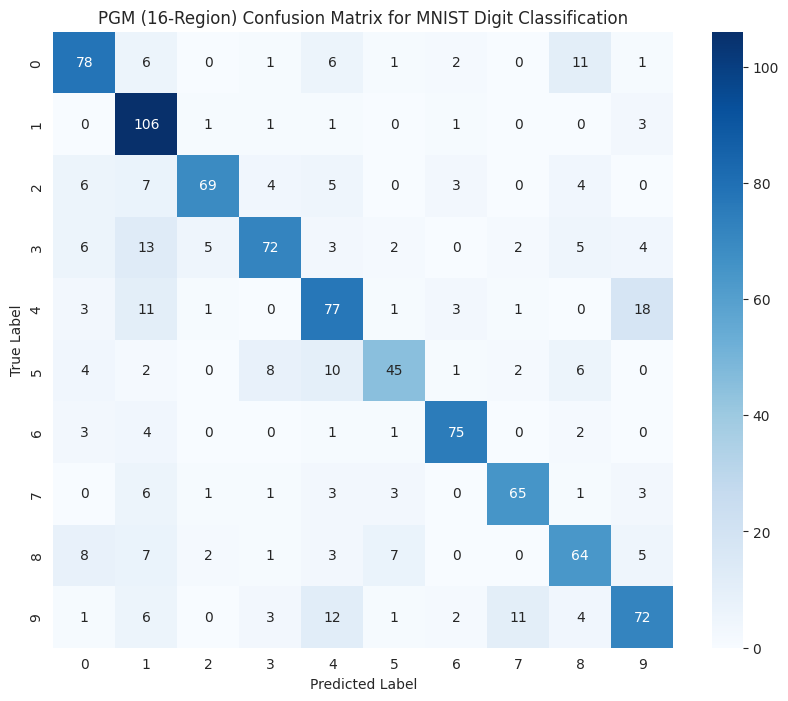

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_16_regions_pgm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PGM (16-Region) Confusion Matrix for MNIST Digit Classification')
plt.show()

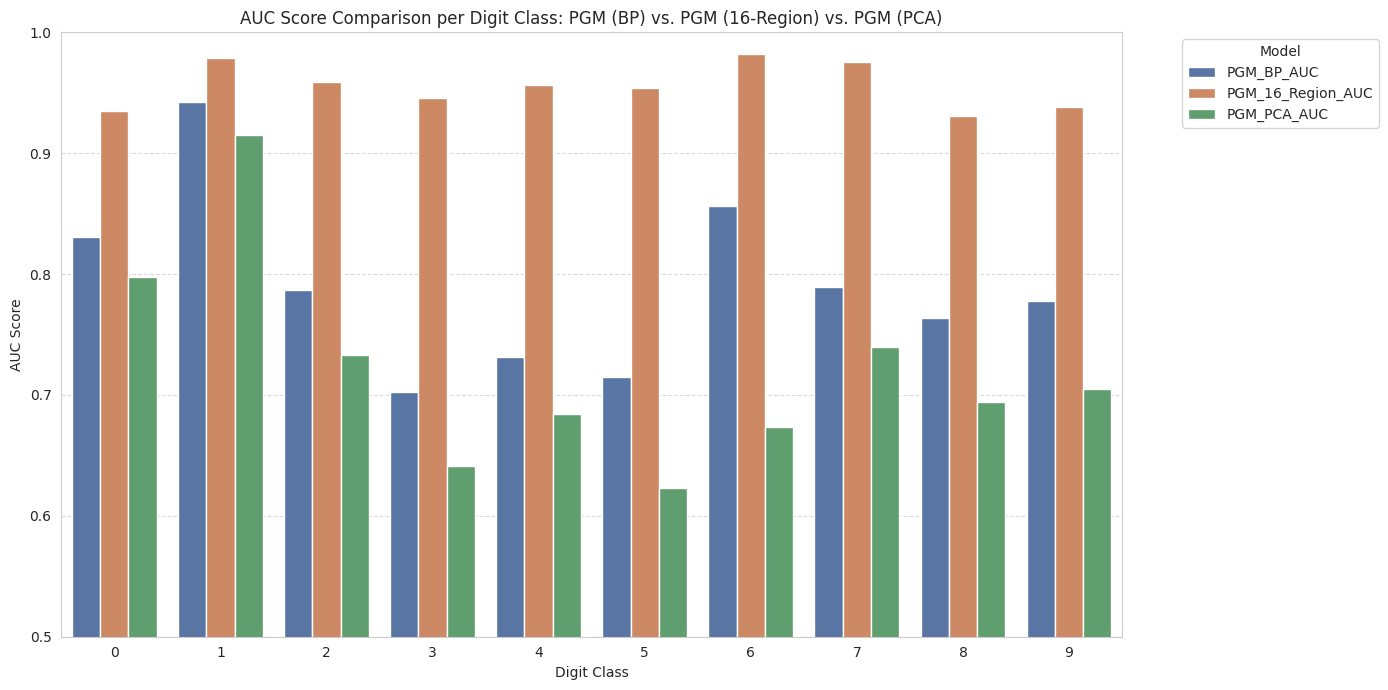

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract AUCs from previous outputs
# PGM AUCs (from 'roc_auc_bp' dictionary for Belief Propagation)
pgm_bp_auc = [
    roc_auc_bp[i] for i in range(digit_label_cardinality)
]

# PGM AUCs (from 'roc_auc_16_regions' dictionary for 16-Region features)
pgm_16_regions_auc = [
    roc_auc_16_regions[i] for i in range(digit_label_cardinality)
]

# PGM AUCs (from 'roc_auc_pca' dictionary for PCA features)
pgm_pca_auc = [
    roc_auc_pca[i] for i in range(digit_label_cardinality)
]

# Create a DataFrame for AUC comparison per digit class
auc_comparison_all_pgm_df = pd.DataFrame({
    'Digit Class': list(range(digit_label_cardinality)),
    'PGM_BP_AUC': pgm_bp_auc,
    'PGM_16_Region_AUC': pgm_16_regions_auc,
    'PGM_PCA_AUC': pgm_pca_auc
})

# Melt the DataFrame for easier plotting with Seaborn
auc_melted_all_pgm_df = auc_comparison_all_pgm_df.melt(id_vars='Digit Class', var_name='Model', value_name='AUC')

# Plot AUC comparison per digit class for all PGM variations
plt.figure(figsize=(14, 7))
sns.barplot(x='Digit Class', y='AUC', hue='Model', data=auc_melted_all_pgm_df, palette='deep')
plt.title('AUC Score Comparison per Digit Class: PGM (BP) vs. PGM (16-Region) vs. PGM (PCA)')
plt.ylabel('AUC Score')
plt.xlabel('Digit Class')
plt.ylim(0.5, 1) # AUC scores typically range from 0.5 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
def discretize_feature_3_bins(value, feature_name, quantiles_df):
    # Using 3 bins: 'low', 'medium', 'high'
    q33 = quantiles_df.loc[0.33, feature_name]
    q66 = quantiles_df.loc[0.66, feature_name]

    if value <= q33:
        return 'low'
    elif value <= q66:
        return 'medium'
    else:
        return 'high'

print("discretize_feature_3_bins function defined successfully.")

discretize_feature_3_bins function defined successfully.


In [ ]:
quantiles_3_bins_df = raw_features_df.quantile([0.33, 0.66])

print("Calculated 33rd and 66th percentiles for 4-quadrant features:")
print(quantiles_3_bins_df)

Calculated 33rd and 66th percentiles for 4-quadrant features:
            TL        TR        BL        BR
0.33  0.083120  0.117915  0.103042  0.123003
0.66  0.120456  0.163113  0.154790  0.169762


In [ ]:
discrete_features_3_bins = raw_features_df.copy()
for col in raw_features_df.columns:
    discrete_features_3_bins[col] = raw_features_df[col].apply(lambda x: discretize_feature_3_bins(x, col, quantiles_3_bins_df))
discrete_features_3_bins_df = discrete_features_3_bins

print("DataFrame of 3-bin discretized 4-quadrant features created successfully. Displaying first 5 rows:")
print(discrete_features_3_bins_df.head())

DataFrame of 3-bin discretized 4-quadrant features created successfully. Displaying first 5 rows:
       TL    TR      BL      BR
0  medium   low  medium    high
1     low   low  medium     low
2    high  high     low    high
3     low   low     low  medium
4    high   low     low    high


In [ ]:
labels_df_3_bins = pd.DataFrame(y_test_subset, columns=['digit_label'])
pgm_data_3_bins_df = pd.concat([discrete_features_3_bins_df, labels_df_3_bins], axis=1)

print("DataFrame with 3-bin discretized 4-quadrant features and digit labels created successfully. Displaying first 5 rows:")
print(pgm_data_3_bins_df.head())

DataFrame with 3-bin discretized 4-quadrant features and digit labels created successfully. Displaying first 5 rows:
       TL    TR      BL      BR  digit_label
0  medium   low  medium    high            6
1     low   low  medium     low            2
2    high  high     low    high            3
3     low   low     low  medium            7
4    high   low     low    high            2


In [ ]:
edges_3_bins = [
    ('digit_label', 'TL'), # digit_label influences Top-Left quadrant
    ('digit_label', 'TR'), # digit_label influences Top-Right quadrant
    ('digit_label', 'BL'), # digit_label influences Bottom-Left quadrant
    ('digit_label', 'BR')  # digit_label influences Bottom-Right quadrant
]
bn_model_3_bins = DiscreteBayesianNetwork(edges_3_bins)

print("Bayesian Network structure for 3-bin features created successfully.")

Bayesian Network structure for 3-bin features created successfully.


In [ ]:
quadrant_cardinality_3_bins = 3 # Number of bins for discretized quadrant features
quadrant_categories_3_bins = ['low', 'medium', 'high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label (reusing previous logic, as y_test_subset is the same)
digit_counts_3_bins = pgm_data_3_bins_df['digit_label'].value_counts().sort_index()
digit_probabilities_3_bins = digit_counts_3_bins.values / len(pgm_data_3_bins_df)
digit_probabilities_3_bins_2d = digit_probabilities_3_bins.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label_3_bins = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_3_bins_2d
)

cpd_quadrants_3_bins = []
category_map_3_bins = {cat: i for i, cat in enumerate(quadrant_categories_3_bins)} # Map category names to numerical indices

# Create CPDs for each quadrant feature given the digit_label
for quadrant_feature in ['TL', 'TR', 'BL', 'BR']:
    values_3_bins = np.zeros((quadrant_cardinality_3_bins, digit_label_cardinality))

    for digit in range(digit_label_cardinality):
        digit_data_3_bins = pgm_data_3_bins_df[pgm_data_3_bins_df['digit_label'] == digit] # Filter data for the current digit
        if not digit_data_3_bins.empty:
            quadrant_counts_3_bins = digit_data_3_bins[quadrant_feature].value_counts() # Count occurrences of each quadrant category for the digit
            for category, count in quadrant_counts_3_bins.items():
                if category in category_map_3_bins:
                    values_3_bins[category_map_3_bins[category], digit] = count / len(digit_data_3_bins) # Calculate conditional probability
            col_sum_3_bins = np.sum(values_3_bins[:, digit])
            # Ensure probabilities sum to 1 for each digit column (marginalizing over quadrant categories)
            if col_sum_3_bins > 0:
                values_3_bins[:, digit] /= col_sum_3_bins

    cpd_3_bins = TabularCPD(
        variable=quadrant_feature,
        variable_card=quadrant_cardinality_3_bins,
        values=values_3_bins,
        evidence=['digit_label'],
        evidence_card=[digit_label_cardinality],
        state_names={
            quadrant_feature: quadrant_categories_3_bins, # Assign human-readable state names for quadrants
            'digit_label': list(range(digit_label_cardinality))
        }
    )
    cpd_quadrants_3_bins.append(cpd_3_bins)
bn_model_3_bins.add_cpds(cpd_digit_label_3_bins, *cpd_quadrants_3_bins) # Add all CPDs to the Bayesian Network model

# Check if the model is consistent after adding all CPDs
print("\nBayesian Network for 3-bin features is consistent after adding all CPDs:", bn_model_3_bins.check_model())


Bayesian Network for 3-bin features is consistent after adding all CPDs: True


In [ ]:
infer_3_bins = VariableElimination(bn_model_3_bins)

pgm_predictions_3_bins = []
pgm_true_labels_3_bins = []

print("Generating PGM (3-bin) predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract raw quadrant features
    current_raw_features = extract_quadrant_features(img_raw.squeeze())

    # Discretize the raw quadrant features using the 3-bin method
    current_discrete_features_3_bins = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features_3_bins[feature_name] = discretize_feature_3_bins(value, feature_name, quantiles_3_bins_df)

    # Perform inference
    query_result_3_bins = infer_3_bins.query(variables=['digit_label'], evidence=current_discrete_features_3_bins)
    predicted_label = query_result_3_bins.values.argmax()

    pgm_predictions_3_bins.append(predicted_label)
    pgm_true_labels_3_bins.append(y_test_subset[i])

print("Predictions generated for 3-bin PGM. Calculating metrics...")

Generating PGM (3-bin) predictions for the test subset...
Predictions generated for 3-bin PGM. Calculating metrics...


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Calculate the confusion matrix for 3-bin PGM
cm_3_bins = confusion_matrix(pgm_true_labels_3_bins, pgm_predictions_3_bins, labels=range(digit_label_cardinality))

# Print classification report for 3-bin PGM
print("\nPGM (3-bin) Classification Report:")
print(classification_report(pgm_true_labels_3_bins, pgm_predictions_3_bins, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("\nPGM (3-bin) Confusion Matrix:")
print(cm_3_bins)


PGM (3-bin) Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.62      0.43       106
           1       0.40      0.76      0.52       113
           2       0.37      0.43      0.39        98
           3       0.33      0.11      0.16       112
           4       0.25      0.24      0.25       115
           5       0.50      0.03      0.05        78
           6       0.49      0.37      0.42        86
           7       0.28      0.18      0.22        83
           8       0.14      0.10      0.12        97
           9       0.26      0.29      0.28       112

    accuracy                           0.33      1000
   macro avg       0.34      0.31      0.28      1000
weighted avg       0.33      0.33      0.29      1000


PGM (3-bin) Confusion Matrix:
[[66 10 10  1  2  0  1  1  2 13]
 [ 0 86 15  1  5  1  1  4  0  0]
 [22 17 42  0  7  0  3  2  3  2]
 [24 16 11 12 13  0  2  5 18 11]
 [13 20  8  3 28  0 12  5  3 23]
 [12 15  

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Re-generate predictions to get probabilities for each class (needed for ROC curve)
pgm_pred_probs_3_bins = []

print("Generating PGM (3-bin) prediction probabilities for ROC analysis...")
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features_3_bins = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features_3_bins[feature_name] = discretize_feature_3_bins(value, feature_name, quantiles_3_bins_df)

    query_result_3_bins = infer_3_bins.query(variables=['digit_label'], evidence=current_discrete_features_3_bins)
    pgm_pred_probs_3_bins.append(query_result_3_bins.values.flatten())

pgm_pred_probs_3_bins = np.array(pgm_pred_probs_3_bins)

# Binarize the true labels for one-vs-rest ROC calculation
label_binarizer = LabelBinarizer()
y_true_binarized_3_bins = label_binarizer.fit_transform(pgm_true_labels_3_bins)

# Compute ROC curve and ROC area for each class
fpr_3_bins = dict()
tpr_3_bins = dict()
roc_auc_3_bins = dict()

for i in range(digit_label_cardinality):
    if pgm_pred_probs_3_bins.shape[1] > i:
        fpr_3_bins[i], tpr_3_bins[i], _ = roc_curve(y_true_binarized_3_bins[:, i], pgm_pred_probs_3_bins[:, i])
        roc_auc_3_bins[i] = auc(fpr_3_bins[i], tpr_3_bins[i])

print("\nAUC for each class (PGM - 3-bin discretization):")
for i in range(digit_label_cardinality):
    if i in roc_auc_3_bins:
        print(f"Class {i}: {roc_auc_3_bins[i]:.2f}")

Generating PGM (3-bin) prediction probabilities for ROC analysis...

AUC for each class (PGM - 3-bin discretization):
Class 0: 0.80
Class 1: 0.89
Class 2: 0.77
Class 3: 0.67
Class 4: 0.73
Class 5: 0.66
Class 6: 0.81
Class 7: 0.75
Class 8: 0.74
Class 9: 0.73


In [ ]:
import cv2

def generate_gabor_kernels(ksize=(31, 31), sigma=5.0, theta_angles=np.arange(0, np.pi, np.pi/4), lambd=10.0, gamma=0.5, psi=0):
    kernels = []
    for theta in theta_angles:
        # ksize: size of the filter
        # sigma: standard deviation of the Gaussian envelope
        # theta: orientation of the normal to the parallel stripes of a Gabor function
        # lambd: wavelength of the sinusoidal factor
        # gamma: spatial aspect ratio
        # psi: phase offset
        # ktype: type of filter coefficients. CV_32F or CV_64F
        kernel = cv2.getGaborKernel(ksize, sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)
        kernels.append(kernel)
    return kernels

print("generate_gabor_kernels function defined successfully.")

generate_gabor_kernels function defined successfully.


In [ ]:
def extract_gabor_features(image, gabor_kernels):
    features = []
    for i, kernel in enumerate(gabor_kernels):
        # Apply Gabor filter to the image
        # The image needs to be 2D (grayscale) for cv2.filter2D
        filtered_image = cv2.filter2D(image, cv2.CV_32F, kernel)
        # Extract feature (e.g., mean intensity) from the filtered image
        features.append(np.mean(np.abs(filtered_image))) # Use absolute value to capture magnitude of response
    return features

print("extract_gabor_features function defined successfully.")

extract_gabor_features function defined successfully.


In [ ]:
gabor_kernels = generate_gabor_kernels() # Generate Gabor kernels with default parameters

# Extract Gabor features for each image in the subset
raw_gabor_features = []
for img in x_test_subset:
    raw_gabor_features.append(extract_gabor_features(img.squeeze(), gabor_kernels))
raw_gabor_features_df = pd.DataFrame(raw_gabor_features) # Convert extracted features to a DataFrame

print("DataFrame of Gabor features created successfully. Displaying first 5 rows:")
print(raw_gabor_features_df.head())

DataFrame of Gabor features created successfully. Displaying first 5 rows:
          0         1          2         3
0  5.346007  8.803362   5.487721  5.814639
1  4.532985  6.703537   6.528827  3.762188
2  5.738058  6.409183  11.799727  6.742791
3  6.339717  3.897390   4.348566  4.345653
4  4.446346  5.674373  10.551460  5.436563


In [ ]:
gabor_quantiles_df = raw_gabor_features_df.quantile([0.20, 0.40, 0.60, 0.80])

discrete_gabor_features = raw_gabor_features_df.copy()
for col in raw_gabor_features_df.columns:
    discrete_gabor_features[col] = raw_gabor_features_df[col].apply(lambda x: discretize_feature(x, col, gabor_quantiles_df))
discrete_gabor_features_df = discrete_gabor_features

print("DataFrame of discretized Gabor features created successfully. Displaying first 5 rows:")
print(discrete_gabor_features_df.head())

DataFrame of discretized Gabor features created successfully. Displaying first 5 rows:
          0          1          2          3
0       low  very_high     medium       high
1  very_low       high     medium        low
2       low       high  very_high  very_high
3    medium   very_low        low     medium
4  very_low     medium  very_high       high


In [ ]:
labels_df_gabor = pd.DataFrame(y_test_subset, columns=['digit_label'])
pgm_data_gabor_df = pd.concat([discrete_gabor_features_df, labels_df_gabor], axis=1)

print("DataFrame with discretized Gabor features and digit labels created successfully. Displaying first 5 rows:")
print(pgm_data_gabor_df.head())

DataFrame with discretized Gabor features and digit labels created successfully. Displaying first 5 rows:
          0          1          2          3  digit_label
0       low  very_high     medium       high            6
1  very_low       high     medium        low            2
2       low       high  very_high  very_high            3
3    medium   very_low        low     medium            7
4  very_low     medium  very_high       high            2


In [ ]:
edges_gabor = []
for col in discrete_gabor_features_df.columns:
    edges_gabor.append(('digit_label', col))
bn_model_gabor = DiscreteBayesianNetwork(edges_gabor)

print(f"Bayesian Network structure for Gabor features created successfully. Number of edges: {len(bn_model_gabor.edges())}")
print("Edges in the model:", bn_model_gabor.edges())

Bayesian Network structure for Gabor features created successfully. Number of edges: 4
Edges in the model: [('digit_label', 0), ('digit_label', 1), ('digit_label', 2), ('digit_label', 3)]


In [ ]:
quadrant_cardinality = 5 # Number of bins for discretized Gabor features
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label from the Gabor data
digit_counts_gabor = pgm_data_gabor_df['digit_label'].value_counts().sort_index()
digit_probabilities_gabor = digit_counts_gabor.values / len(pgm_data_gabor_df)
digit_probabilities_gabor_2d = digit_probabilities_gabor.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label_gabor = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_gabor_2d
)

cpd_gabor_features = []
category_map_gabor = {cat: i for i, cat in enumerate(quadrant_categories)} # Map category names to numerical indices

# Create CPDs for each Gabor feature given the digit_label
for gabor_feature_col in discrete_gabor_features_df.columns:
    values_gabor = np.zeros((quadrant_cardinality, digit_label_cardinality))

    for digit in range(digit_label_cardinality):
        digit_data_gabor = pgm_data_gabor_df[pgm_data_gabor_df['digit_label'] == digit] # Filter data for the current digit
        if not digit_data_gabor.empty:
            feature_counts_gabor = digit_data_gabor[gabor_feature_col].value_counts() # Count occurrences of each Gabor feature category for the digit
            for category, count in feature_counts_gabor.items():
                if category in category_map_gabor:
                    values_gabor[category_map_gabor[category], digit] = count / len(digit_data_gabor) # Calculate conditional probability
            col_sum_gabor = np.sum(values_gabor[:, digit])
            # Ensure probabilities sum to 1 for each digit column (marginalizing over Gabor categories)
            if col_sum_gabor > 0:
                values_gabor[:, digit] /= col_sum_gabor

    cpd_gabor = TabularCPD(
        variable=gabor_feature_col,
        variable_card=quadrant_cardinality,
        values=values_gabor,
        evidence=['digit_label'],
        evidence_card=[digit_label_cardinality],
        state_names={
            gabor_feature_col: quadrant_categories, # Assign human-readable state names for Gabor features
            'digit_label': list(range(digit_label_cardinality))
        }
    )
    cpd_gabor_features.append(cpd_gabor)
bn_model_gabor.add_cpds(cpd_digit_label_gabor, *cpd_gabor_features) # Add all CPDs to the Bayesian Network model

# Check if the model is consistent after adding all CPDs
print("\nBayesian Network for Gabor features is consistent after adding all CPDs:", bn_model_gabor.check_model())


Bayesian Network for Gabor features is consistent after adding all CPDs: True


In [ ]:
infer_gabor = VariableElimination(bn_model_gabor)

# Select a test image that was not part of the PGM training data
# (using the same logic as before to avoid data leakage from the original 4-quadrant PGM training)
all_test_indices = set(range(len(x_test)))
pgm_train_indices_subset = set(sample_indices)
available_test_indices_for_gabor = list(all_test_indices - pgm_train_indices_subset)

# If no new indices are available, just pick one from the existing subset (though less ideal for 'unseen')
if not available_test_indices_for_gabor:
    test_img_idx_gabor = np.random.choice(len(x_test))
else:
    test_img_idx_gabor = np.random.choice(available_test_indices_for_gabor)

query_image_gabor = x_test[test_img_idx_gabor]
true_label_gabor = y_test[test_img_idx_gabor]

# Extract raw Gabor features for the selected image
raw_features_query_gabor = extract_gabor_features(query_image_gabor.squeeze(), gabor_kernels)
raw_features_query_gabor_df = pd.DataFrame([raw_features_query_gabor])

# Discretize the Gabor features of the selected test image
discrete_gabor_features_query = {}
for col in raw_features_query_gabor_df.columns:
    discrete_gabor_features_query[col] = raw_features_query_gabor_df[col].apply(lambda x: discretize_feature(x, col, gabor_quantiles_df)).iloc[0]

# Perform inference to predict the digit label based on the discretized Gabor features
query_result_gabor = infer_gabor.query(variables=['digit_label'], evidence=discrete_gabor_features_query)
predicted_label_gabor = query_result_gabor.values.argmax()

print(f"\nSelected test image index (Gabor): {test_img_idx_gabor}")
print(f"True Label (Gabor): {true_label_gabor}")
print(f"Raw Gabor Features: {raw_features_query_gabor}")
print(f"Discretized Gabor Features: {discrete_gabor_features_query}")
print(f"Predicted Label (Gabor): {predicted_label_gabor}")
print("\nProbability distribution over digit_label (Gabor):")
print(query_result_gabor)


Selected test image index (Gabor): 715
True Label (Gabor): 2
Raw Gabor Features: [np.float32(4.8492866), np.float32(9.320804), np.float32(11.726022), np.float32(4.0160327)]
Discretized Gabor Features: {0: 'very_low', 1: 'very_high', 2: 'very_high', 3: 'low'}
Predicted Label (Gabor): 2

Probability distribution over digit_label (Gabor):
+----------------+--------------------+
| digit_label    |   phi(digit_label) |
+================+====================+
| digit_label(0) |             0.0931 |
+----------------+--------------------+
| digit_label(1) |             0.0000 |
+----------------+--------------------+
| digit_label(2) |             0.6659 |
+----------------+--------------------+
| digit_label(3) |             0.0405 |
+----------------+--------------------+
| digit_label(4) |             0.0075 |
+----------------+--------------------+
| digit_label(5) |             0.0686 |
+----------------+--------------------+
| digit_label(6) |             0.0260 |
+----------------+---

In [ ]:
pgm_gabor_predictions = []
pgm_gabor_true_labels = []

print("Generating PGM (Gabor) predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract raw Gabor features for the current image
    current_raw_features_gabor = extract_gabor_features(img_raw.squeeze(), gabor_kernels)
    current_raw_features_gabor_df = pd.DataFrame([current_raw_features_gabor])

    # Discretize the Gabor features
    current_discrete_gabor_features = {}
    for col in current_raw_features_gabor_df.columns:
        current_discrete_gabor_features[col] = current_raw_features_gabor_df[col].apply(lambda x: discretize_feature(x, col, gabor_quantiles_df)).iloc[0]

    # Perform inference
    query_result_gabor_subset = infer_gabor.query(variables=['digit_label'], evidence=current_discrete_gabor_features)
    predicted_label = query_result_gabor_subset.values.argmax()

    pgm_gabor_predictions.append(predicted_label)
    pgm_gabor_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix and classification report...")

# Calculate the confusion matrix
cm_gabor_pgm = confusion_matrix(pgm_gabor_true_labels, pgm_gabor_predictions, labels=range(digit_label_cardinality))

# Print classification report
print("\nPGM (Gabor) Classification Report:")
print(classification_report(pgm_gabor_true_labels, pgm_gabor_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("\nPGM (Gabor) Confusion Matrix:")
print(cm_gabor_pgm)

Generating PGM (Gabor) predictions for the test subset...
Predictions generated. Calculating confusion matrix and classification report...

PGM (Gabor) Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.61      0.53       106
           1       0.63      0.89      0.74       113
           2       0.60      0.38      0.46        98
           3       0.43      0.48      0.45       112
           4       0.44      0.35      0.39       115
           5       0.42      0.21      0.28        78
           6       0.34      0.35      0.34        86
           7       0.33      0.35      0.34        83
           8       0.39      0.43      0.41        97
           9       0.37      0.33      0.35       112

    accuracy                           0.45      1000
   macro avg       0.44      0.44      0.43      1000
weighted avg       0.45      0.45      0.44      1000


PGM (Gabor) Confusion Matrix:
[[ 65   1   4   4   5   3   6   7  

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Re-generate predictions to get probabilities for each class (needed for ROC curve)
pgm_gabor_pred_probs = []

print("Generating PGM (Gabor) prediction probabilities for ROC analysis...")
for i, img_raw in enumerate(x_test_subset):
    current_raw_features_gabor = extract_gabor_features(img_raw.squeeze(), gabor_kernels)
    current_raw_features_gabor_df = pd.DataFrame([current_raw_features_gabor])

    current_discrete_gabor_features = {}
    for col in current_raw_features_gabor_df.columns:
        current_discrete_gabor_features[col] = current_raw_features_gabor_df[col].apply(lambda x: discretize_feature(x, col, gabor_quantiles_df)).iloc[0]

    query_result_gabor_subset = infer_gabor.query(variables=['digit_label'], evidence=current_discrete_gabor_features)
    pgm_gabor_pred_probs.append(query_result_gabor_subset.values.flatten())

pgm_gabor_pred_probs = np.array(pgm_gabor_pred_probs)

# Binarize the true labels for one-vs-rest ROC calculation
label_binarizer = LabelBinarizer()
y_true_binarized_gabor = label_binarizer.fit_transform(pgm_gabor_true_labels)

# Compute ROC curve and ROC area for each class
fpr_gabor = dict()
tpr_gabor = dict()
roc_auc_gabor = dict()

for i in range(digit_label_cardinality):
    if pgm_gabor_pred_probs.shape[1] > i:
        fpr_gabor[i], tpr_gabor[i], _ = roc_curve(y_true_binarized_gabor[:, i], pgm_gabor_pred_probs[:, i])
        roc_auc_gabor[i] = auc(fpr_gabor[i], tpr_gabor[i])

print("\nAUC for each class (PGM - Gabor features):")
for i in range(digit_label_cardinality):
    if i in roc_auc_gabor:
        print(f"Class {i}: {roc_auc_gabor[i]:.2f}")

Generating PGM (Gabor) prediction probabilities for ROC analysis...

AUC for each class (PGM - Gabor features):
Class 0: 0.85
Class 1: 0.97
Class 2: 0.87
Class 3: 0.85
Class 4: 0.82
Class 5: 0.87
Class 6: 0.81
Class 7: 0.77
Class 8: 0.81
Class 9: 0.81


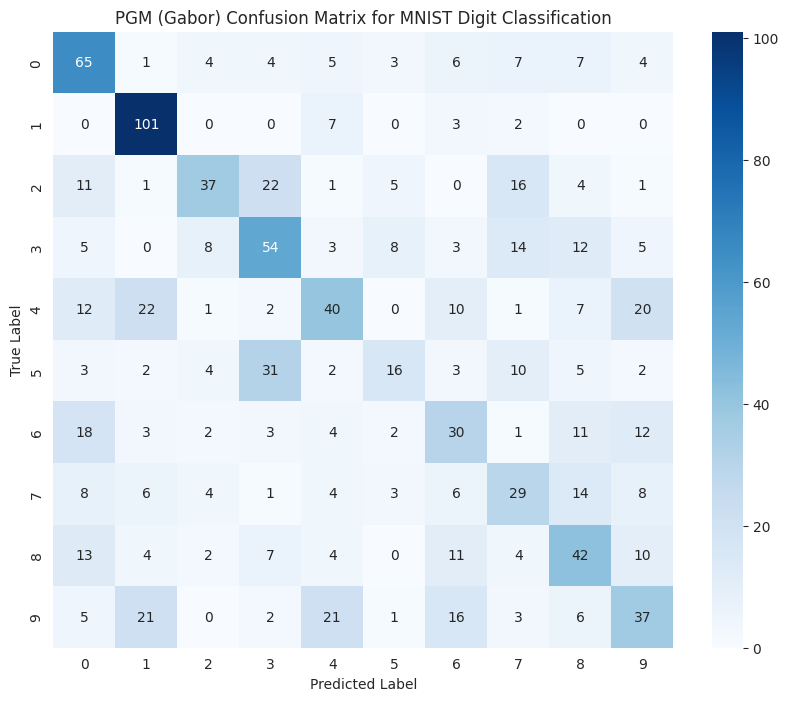

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_gabor_pgm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PGM (Gabor) Confusion Matrix for MNIST Digit Classification')
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means clustering to the raw_features_16_regions_df
k_means_model = KMeans(n_clusters=10, random_state=42, n_init=10)  # Assuming 10 digits/clusters
cluster_labels = k_means_model.fit_predict(raw_features_16_regions_df)

# Add cluster labels to a new DataFrame for analysis
clustered_data_16_regions_df = raw_features_16_regions_df.copy()
clustered_data_16_regions_df['cluster_label'] = cluster_labels
clustered_data_16_regions_df['true_label'] = y_test_subset

print("K-Means clustering applied successfully to 16-region features.")
print("First 5 rows of clustered data with true labels:")
print(clustered_data_16_regions_df[['cluster_label', 'true_label']].head())

K-Means clustering applied successfully to 16-region features.
First 5 rows of clustered data with true labels:
   cluster_label  true_label
0              5           6
1              7           2
2              2           3
3              8           7
4              9           2



Contingency Matrix (Cluster Labels vs. True Labels):
true_label      0   1   2   3   4   5   6   7   8   9
cluster_label                                        
0               1   0   0  14   0  16   0  39   4  19
1              28   1   3   4   9   7   4   5  26  16
2               0   1   7  49   0   1   0   0   5   1
3              30   1   2   4   0  33   6   0  11   0
4              29   0   4   5   5   4   2   0  26   4
5               9   0   8   1  38   7  41   1   1   2
6               1   0  43   1   5   0  30   0   1   0
7               1  63  23   6   3   3   0   5   3   3
8               6  44   5  21  10   6   2  19   5   7
9               1   3   3   7  45   1   1  14  15  60


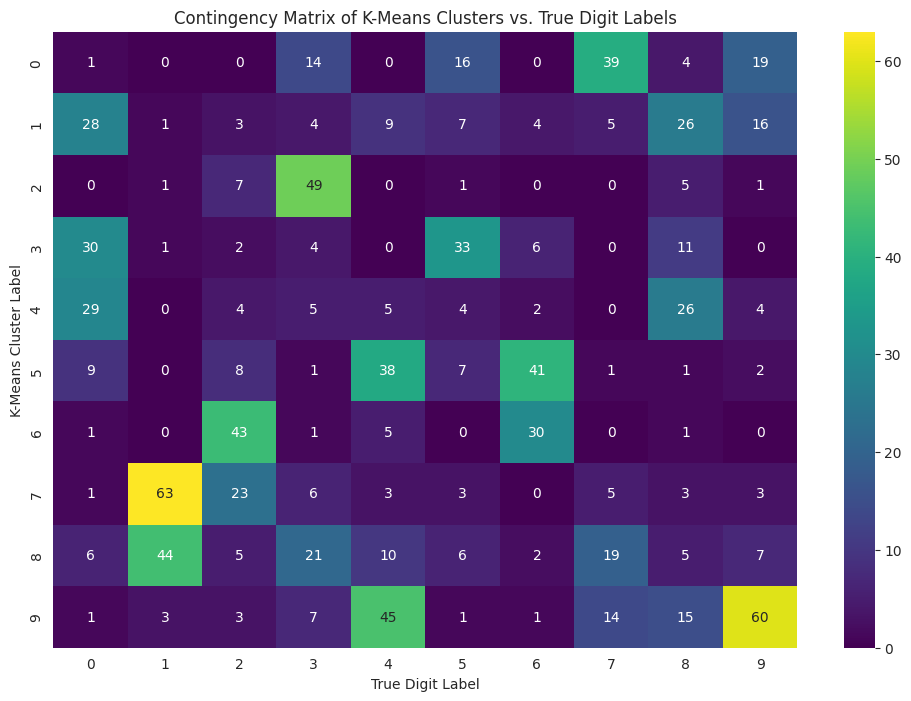

In [ ]:
from sklearn.metrics import confusion_matrix

# Create a contingency matrix (cross-tabulation) to see the distribution of true labels within each cluster
contingency_matrix = pd.crosstab(clustered_data_16_regions_df['cluster_label'], clustered_data_16_regions_df['true_label'])

print("\nContingency Matrix (Cluster Labels vs. True Labels):")
print(contingency_matrix)

# Optional: Visualize the contingency matrix as a heatmap for better understanding
plt.figure(figsize=(12, 8))
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='viridis')
plt.title('Contingency Matrix of K-Means Clusters vs. True Digit Labels')
plt.xlabel('True Digit Label')
plt.ylabel('K-Means Cluster Label')
plt.show()


In [ ]:
def extract_quadrant_features(image):
    h, w = image.shape[0], image.shape[1]
    h_mid, w_mid = h // 2, w // 2
    # Calculate mean intensity for each quadrant
    features = {
        'TL': np.mean(image[0:h_mid, 0:w_mid]),  # Top-Left
        'TR': np.mean(image[0:h_mid, w_mid:w]),  # Top-Right
        'BL': np.mean(image[h_mid:h, 0:w_mid]),  # Bottom-Left
        'BR': np.mean(image[h_mid:h, w_mid:w])   # Bottom-Right
    }
    return features

def discretize_feature(value, feature_name, quantiles_df):
    # Using 5 bins: 'very_low', 'low', 'medium', 'high', 'very_high'
    q20 = quantiles_df.loc[0.20, feature_name]
    q40 = quantiles_df.loc[0.40, feature_name]
    q60 = quantiles_df.loc[0.60, feature_name]
    q80 = quantiles_df.loc[0.80, feature_name]

    if value <= q20:
        return 'very_low'
    elif value <= q40:
        return 'low'
    elif value <= q60:
        return 'medium'
    elif value <= q80:
        return 'high'
    else:
        return 'very_high'

def discretize_feature_3_bins(value, feature_name, quantiles_df):
    # Using 3 bins: 'low', 'medium', 'high'
    q33 = quantiles_df.loc[0.33, feature_name]
    q66 = quantiles_df.loc[0.66, feature_name]

    if value <= q33:
        return 'low'
    elif value <= q66:
        return 'medium'
    else:
        return 'high'

def generate_gabor_kernels(ksize=(31, 31), sigma=5.0, theta_angles=np.arange(0, np.pi, np.pi/4), lambd=10.0, gamma=0.5, psi=0):
    kernels = []
    for theta in theta_angles:
        kernel = cv2.getGaborKernel(ksize, sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)
        kernels.append(kernel)
    return kernels

def extract_gabor_features(image, gabor_kernels):
    features = []
    for i, kernel in enumerate(gabor_kernels):
        filtered_image = cv2.filter2D(image, cv2.CV_32F, kernel)
        features.append(np.mean(np.abs(filtered_image)))
    return features

def extract_16_region_features(image):
    h, w = image.shape[0], image.shape[1]
    h_region, w_region = h // 4, w // 4
    features = {}
    for i in range(4):
        for j in range(4):
            region = image[i*h_region:(i+1)*h_region, j*w_region:(j+1)*w_region]
            features[f'R{i+1}C{j+1}'] = np.mean(region)
    return features

print("All feature extraction and discretization functions defined successfully.")

All feature extraction and discretization functions defined successfully.


In [ ]:
import numpy as np
import pandas as pd

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and reshape x_test
x_test = x_test.astype('float32') / 255.
x_test = np.expand_dims(x_test, -1) # Add channel dimension

# Define the number of samples to use for PGM analysis
# This number is kept consistent with previous runs (1000 samples)
num_samples = 1000

# Ensure reproducibility by setting a random seed
np.random.seed(42)

# Select a random subset of test indices for consistent PGM analysis
sample_indices = np.random.choice(len(x_test), num_samples, replace=False)
x_test_subset = x_test[sample_indices]
y_test_subset = y_test[sample_indices]

# Extract 4-quadrant features for the initial PGM setup
raw_features = []
for img in x_test_subset:
    raw_features.append(extract_quadrant_features(img.squeeze()))
raw_features_df = pd.DataFrame(raw_features)

print(f"MNIST data loaded and preprocessed.")
print(f"Selected {num_samples} samples for PGM analysis.")
print(f"Shape of x_test_subset: {x_test_subset.shape}")
print(f"Shape of y_test_subset: {y_test_subset.shape}")
print(f"Shape of raw_features_df: {raw_features_df.shape}")
print("First 5 rows of raw_features_df:")
print(raw_features_df.head())

MNIST data loaded and preprocessed.
Selected 1000 samples for PGM analysis.
Shape of x_test_subset: (1000, 28, 28, 1)
Shape of y_test_subset: (1000,)
Shape of raw_features_df: (1000, 4)
First 5 rows of raw_features_df:
         TL        TR        BL        BR
0  0.110844  0.081192  0.113585  0.192457
1  0.028211  0.109224  0.144258  0.105022
2  0.158884  0.173749  0.101821  0.204102
3  0.074050  0.071849  0.025930  0.166407
4  0.126130  0.099600  0.041817  0.185834


In [ ]:
def setup_pgm_model(feature_df, quantiles_df, feature_cols, digit_labels, discretization_func, quadrant_cardinality=5, quadrant_categories=None):
    """
    Sets up a Bayesian Network model with the given features and digit labels.

    Args:
        feature_df (pd.DataFrame): DataFrame containing the raw features.
        quantiles_df (pd.DataFrame): DataFrame containing quantiles for discretization.
        feature_cols (list): List of column names in feature_df to be used as nodes.
        digit_labels (np.array): Array of true digit labels.
        discretization_func (function): Function to discretize continuous features.
        quadrant_cardinality (int): Number of bins used for discretization.
        quadrant_categories (list): List of category names for the discretized features.

    Returns:
        tuple: A tuple containing the configured Bayesian Network model and its inference engine.
    """
    if quadrant_categories is None:
        # Default categories for 5 bins
        quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high']

    digit_label_cardinality = 10

    # 1. Discretize features
    discrete_features = feature_df.copy()
    for col in feature_cols:
        discrete_features[col] = feature_df[col].apply(lambda x: discretization_func(x, col, quantiles_df))

    # 2. Combine with digit labels
    labels_df = pd.DataFrame(digit_labels, columns=['digit_label'])
    pgm_data_df = pd.concat([discrete_features, labels_df], axis=1)

    # 3. Define Bayesian Network structure
    edges = []
    for col in feature_cols:
        edges.append(('digit_label', col))
    bn_model = DiscreteBayesianNetwork(edges)

    # 4. Calculate prior probabilities for digit_label
    digit_counts = pgm_data_df['digit_label'].value_counts().sort_index()
    digit_probabilities = digit_counts.values / len(pgm_data_df)
    cpd_digit_label = TabularCPD(
        variable='digit_label',
        variable_card=digit_label_cardinality,
        values=digit_probabilities.reshape(-1, 1)
    )

    # 5. Create CPDs for each feature given digit_label
    cpd_features = []
    category_map = {cat: i for i, cat in enumerate(quadrant_categories)}

    for feature_name in feature_cols:
        values = np.zeros((quadrant_cardinality, digit_label_cardinality))
        for digit in range(digit_label_cardinality):
            digit_data = pgm_data_df[pgm_data_df['digit_label'] == digit]
            if not digit_data.empty:
                feature_counts = digit_data[feature_name].value_counts()
                for category, count in feature_counts.items():
                    if category in category_map:
                        values[category_map[category], digit] = count / len(digit_data)
                col_sum = np.sum(values[:, digit])
                if col_sum > 0:
                    values[:, digit] /= col_sum

        cpd = TabularCPD(
            variable=feature_name,
            variable_card=quadrant_cardinality,
            values=values,
            evidence=['digit_label'],
            evidence_card=[digit_label_cardinality],
            state_names={
                feature_name: quadrant_categories,
                'digit_label': list(range(digit_label_cardinality))
            }
        )
        cpd_features.append(cpd)

    # Add all CPDs to the model
    bn_model.add_cpds(cpd_digit_label, *cpd_features)

    # Check consistency
    if not bn_model.check_model():
        raise ValueError("Bayesian Network model is not consistent.")

    infer_engine = VariableElimination(bn_model)

    return bn_model, infer_engine, pgm_data_df, discrete_features

print("setup_pgm_model function defined successfully.")

setup_pgm_model function defined successfully.


In [ ]:
quadrant_cardinality_5_bins = 5
quadrant_categories_5_bins = ['very_low', 'low', 'medium', 'high', 'very_high']
feature_cols_4_quadrant = ['TL', 'TR', 'BL', 'BR']

# Calculate quantiles for 5-bin discretization
quantiles_5_bins_df = raw_features_df.quantile([0.20, 0.40, 0.60, 0.80])

bn_model_4_quadrant_5_bins, infer_4_quadrant_5_bins, pgm_data_4_quadrant_5_bins_df, discrete_features_4_quadrant_5_bins = setup_pgm_model(
    feature_df=raw_features_df,
    quantiles_df=quantiles_5_bins_df,
    feature_cols=feature_cols_4_quadrant,
    digit_labels=y_test_subset,
    discretization_func=discretize_feature,
    quadrant_cardinality=quadrant_cardinality_5_bins,
    quadrant_categories=quadrant_categories_5_bins
)

print("PGM for 4-quadrant features (5-bin) setup successfully.")
print(f"Model consistency check: {bn_model_4_quadrant_5_bins.check_model()}")

PGM for 4-quadrant features (5-bin) setup successfully.
Model consistency check: True


In [ ]:
feature_cols_16_regions = [f'R{i+1}C{j+1}' for i in range(4) for j in range(4)]

# Extract 16-region features for each image in the subset
raw_features_16_regions = []
for img in x_test_subset:
    raw_features_16_regions.append(extract_16_region_features(img.squeeze()))
raw_features_16_regions_df = pd.DataFrame(raw_features_16_regions)

# Calculate quantiles for 5-bin discretization for 16-region features
quantiles_16_regions_df = raw_features_16_regions_df.quantile([0.20, 0.40, 0.60, 0.80])

bn_model_16_regions, infer_16_regions, pgm_data_16_regions_df, discrete_features_16_regions = setup_pgm_model(
    feature_df=raw_features_16_regions_df,
    quantiles_df=quantiles_16_regions_df,
    feature_cols=feature_cols_16_regions,
    digit_labels=y_test_subset,
    discretization_func=discretize_feature,
    quadrant_cardinality=quadrant_cardinality_5_bins, # Reusing 5-bin cardinality
    quadrant_categories=quadrant_categories_5_bins # Reusing 5-bin categories
)

print("PGM for 16-region features (5-bin) setup successfully.")
print(f"Model consistency check: {bn_model_16_regions.check_model()}")

PGM for 16-region features (5-bin) setup successfully.
Model consistency check: True


In [ ]:
feature_cols_pca = ['PC1', 'PC2']

# Apply PCA transformation to the raw 4-quadrant features
pca = PCA(n_components=2) # Initialize PCA to reduce to 2 principal components
pca_features = pca.fit_transform(raw_features_df) # Fit PCA and transform the raw features
pca_features_df = pd.DataFrame(pca_features, columns=feature_cols_pca) # Convert to DataFrame

# Calculate quantiles for 5-bin discretization for PCA features
quantiles_pca_df = pca_features_df.quantile([0.20, 0.40, 0.60, 0.80])

bn_model_pca, infer_pca, pgm_data_pca_df, discrete_pca_features_df = setup_pgm_model(
    feature_df=pca_features_df,
    quantiles_df=quantiles_pca_df,
    feature_cols=feature_cols_pca,
    digit_labels=y_test_subset,
    discretization_func=discretize_feature,
    quadrant_cardinality=quadrant_cardinality_5_bins, # Reusing 5-bin cardinality
    quadrant_categories=quadrant_categories_5_bins # Reusing 5-bin categories
)

print("PGM for PCA features (5-bin) setup successfully.")
print(f"Model consistency check: {bn_model_pca.check_model()}")

PGM for PCA features (5-bin) setup successfully.
Model consistency check: True


In [ ]:
feature_cols_gabor = [col for col in raw_gabor_features_df.columns]

# Generate Gabor kernels (re-run as raw_gabor_features_df was already created using these)
gabor_kernels = generate_gabor_kernels()

# Extract Gabor features for each image in the subset (re-run to ensure raw_gabor_features_df is current)
raw_gabor_features = []
for img in x_test_subset:
    raw_gabor_features.append(extract_gabor_features(img.squeeze(), gabor_kernels))
raw_gabor_features_df = pd.DataFrame(raw_gabor_features)

# Calculate quantiles for 5-bin discretization for Gabor features
gabor_quantiles_df = raw_gabor_features_df.quantile([0.20, 0.40, 0.60, 0.80])

bn_model_gabor, infer_gabor, pgm_data_gabor_df, discrete_gabor_features_df = setup_pgm_model(
    feature_df=raw_gabor_features_df,
    quantiles_df=gabor_quantiles_df,
    feature_cols=feature_cols_gabor,
    digit_labels=y_test_subset,
    discretization_func=discretize_feature,
    quadrant_cardinality=quadrant_cardinality_5_bins, # Reusing 5-bin cardinality
    quadrant_categories=quadrant_categories_5_bins # Reusing 5-bin categories
)

print("PGM for Gabor features (5-bin) setup successfully.")
print(f"Model consistency check: {bn_model_gabor.check_model()}")

PGM for Gabor features (5-bin) setup successfully.
Model consistency check: True


In [ ]:
quadrant_cardinality_3_bins = 3
quadrant_categories_3_bins = ['low', 'medium', 'high']
feature_cols_4_quadrant = ['TL', 'TR', 'BL', 'BR']

# Calculate quantiles for 3-bin discretization
quantiles_3_bins_df = raw_features_df.quantile([0.33, 0.66])

bn_model_4_quadrant_3_bins, infer_4_quadrant_3_bins, pgm_data_4_quadrant_3_bins_df, discrete_features_4_quadrant_3_bins = setup_pgm_model(
    feature_df=raw_features_df,
    quantiles_df=quantiles_3_bins_df,
    feature_cols=feature_cols_4_quadrant,
    digit_labels=y_test_subset,
    discretization_func=discretize_feature_3_bins,
    quadrant_cardinality=quadrant_cardinality_3_bins,
    quadrant_categories=quadrant_categories_3_bins
)

print("PGM for 4-quadrant features (3-bin) setup successfully.")
print(f"Model consistency check: {bn_model_4_quadrant_3_bins.check_model()}")

PGM for 4-quadrant features (3-bin) setup successfully.
Model consistency check: True


In [ ]:
def evaluate_pgm_model(infer_engine, feature_cols, x_test_subset, y_test_subset, quantiles_df, discretization_func, digit_label_cardinality=10):
    """
    Evaluates a PGM model by generating predictions and calculating performance metrics.

    Args:
        infer_engine: The PGM inference engine (e.g., VariableElimination).
        feature_cols (list): List of feature column names used by the PGM.
        x_test_subset (np.array): Subset of test images.
        y_test_subset (np.array): True labels for the test subset.
        quantiles_df (pd.DataFrame): DataFrame containing quantiles for discretization.
        discretization_func (function): Function to discretize continuous features.
        digit_label_cardinality (int): Number of possible digit labels (0-9).

    Returns:
        tuple: predictions, prediction probabilities, classification report, confusion matrix, and AUC scores.
    """
    pgm_predictions = []
    pgm_pred_probs = []

    for i, img_raw in enumerate(x_test_subset):
        current_raw_features_dict = {}
        # Dynamically extract features based on feature_cols
        if 'TL' in feature_cols or 'TR' in feature_cols or 'BL' in feature_cols or 'BR' in feature_cols:
            current_raw_features_dict = extract_quadrant_features(img_raw.squeeze())
        elif 'PC1' in feature_cols or 'PC2' in feature_cols:
            # For PCA features, we need to apply PCA first
            raw_quadrant_features = extract_quadrant_features(img_raw.squeeze())
            raw_quadrant_features_df = pd.DataFrame([raw_quadrant_features])
            current_pca_features = pca.transform(raw_quadrant_features_df)
            current_raw_features_dict = pd.DataFrame(current_pca_features, columns=feature_cols).iloc[0].to_dict()
        elif 'R1C1' in feature_cols:
            current_raw_features_dict = extract_16_region_features(img_raw.squeeze())
        elif 0 in feature_cols or '0' in feature_cols:
            current_raw_features_dict = {i: val for i, val in enumerate(extract_gabor_features(img_raw.squeeze(), gabor_kernels))}

        current_discrete_features = {}
        for feature_name, value in current_raw_features_dict.items():
            current_discrete_features[feature_name] = discretization_func(value, feature_name, quantiles_df)

        query_result = infer_engine.query(variables=['digit_label'], evidence=current_discrete_features)
        predicted_label = query_result.values.argmax()

        pgm_predictions.append(predicted_label)
        pgm_pred_probs.append(query_result.values.flatten())

    pgm_pred_probs = np.array(pgm_pred_probs)

    # Classification Report and Confusion Matrix
    class_report = classification_report(y_test_subset, pgm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)])
    conf_matrix = confusion_matrix(y_test_subset, pgm_predictions, labels=range(digit_label_cardinality))

    # ROC AUC
    label_binarizer = LabelBinarizer()
    y_true_binarized = label_binarizer.fit_transform(y_test_subset)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(digit_label_cardinality):
        if pgm_pred_probs.shape[1] > i:
            fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], pgm_pred_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

    return pgm_predictions, pgm_pred_probs, class_report, conf_matrix, roc_auc

print("evaluate_pgm_model function defined successfully.")

evaluate_pgm_model function defined successfully.


In [ ]:
pgm_predictions_4_quadrant_5_bins, pgm_pred_probs_4_quadrant_5_bins, class_report_4_quadrant_5_bins, conf_matrix_4_quadrant_5_bins, roc_auc_4_quadrant_5_bins = evaluate_pgm_model(
    infer_engine=infer_4_quadrant_5_bins,
    feature_cols=feature_cols_4_quadrant,
    x_test_subset=x_test_subset,
    y_test_subset=y_test_subset,
    quantiles_df=quantiles_5_bins_df,
    discretization_func=discretize_feature
)

print("PGM (4-quadrant, 5-bin) Evaluation Results:")
print("\nClassification Report:")
print(class_report_4_quadrant_5_bins)
print("\nConfusion Matrix:")
print(conf_matrix_4_quadrant_5_bins)
print("\nAUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc_4_quadrant_5_bins:
        print(f"Class {i}: {roc_auc_4_quadrant_5_bins[i]:.2f}")

PGM (4-quadrant, 5-bin) Evaluation Results:

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46       106
           1       0.55      0.81      0.65       113
           2       0.38      0.34      0.36        98
           3       0.33      0.16      0.22       112
           4       0.28      0.34      0.31       115
           5       0.25      0.05      0.09        78
           6       0.55      0.31      0.40        86
           7       0.31      0.19      0.24        83
           8       0.36      0.22      0.27        97
           9       0.28      0.45      0.34       112

    accuracy                           0.37      1000
   macro avg       0.36      0.35      0.33      1000
weighted avg       0.36      0.37      0.34      1000


Confusion Matrix:
[[71  6  8  1  5  3  1  0  2  9]
 [ 0 91  7  1 11  2  0  0  0  1]
 [23 16 33  0 12  0  2  2  3  7]
 [28  9  7 18  8  1  4  7  8 22]
 [12 12  6  5 39  0  9

In [ ]:
pgm_predictions_16_regions, pgm_pred_probs_16_regions, class_report_16_regions, conf_matrix_16_regions, roc_auc_16_regions = evaluate_pgm_model(
    infer_engine=infer_16_regions,
    feature_cols=feature_cols_16_regions,
    x_test_subset=x_test_subset,
    y_test_subset=y_test_subset,
    quantiles_df=quantiles_16_regions_df,
    discretization_func=discretize_feature
)

print("PGM (16-Region, 5-bin) Evaluation Results:")
print("\nClassification Report:")
print(class_report_16_regions)
print("\nConfusion Matrix:")
print(conf_matrix_16_regions)
print("\nAUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc_16_regions:
        print(f"Class {i}: {roc_auc_16_regions[i]:.2f}")

PGM (16-Region, 5-bin) Evaluation Results:

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73       106
           1       0.63      0.94      0.75       113
           2       0.87      0.70      0.78        98
           3       0.79      0.64      0.71       112
           4       0.64      0.67      0.65       115
           5       0.74      0.58      0.65        78
           6       0.86      0.87      0.87        86
           7       0.80      0.78      0.79        83
           8       0.66      0.66      0.66        97
           9       0.68      0.64      0.66       112

    accuracy                           0.72      1000
   macro avg       0.74      0.72      0.72      1000
weighted avg       0.73      0.72      0.72      1000


Confusion Matrix:
[[ 78   6   0   1   6   1   2   0  11   1]
 [  0 106   1   1   1   0   1   0   0   3]
 [  6   7  69   4   5   0   3   0   4   0]
 [  6  13   5  72   3   2 

In [ ]:
pgm_predictions_pca, pgm_pred_probs_pca, class_report_pca, conf_matrix_pca, roc_auc_pca = evaluate_pgm_model(
    infer_engine=infer_pca,
    feature_cols=feature_cols_pca,
    x_test_subset=x_test_subset,
    y_test_subset=y_test_subset,
    quantiles_df=quantiles_pca_df,
    discretization_func=discretize_feature
)

print("PGM (PCA, 5-bin) Evaluation Results:")
print("\nClassification Report:")
print(class_report_pca)
print("\nConfusion Matrix:")
print(conf_matrix_pca)
print("\nAUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc_pca:
        print(f"Class {i}: {roc_auc_pca[i]:.2f}")

PGM (PCA, 5-bin) Evaluation Results:

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.46      0.37       106
           1       0.45      0.80      0.58       113
           2       0.24      0.30      0.26        98
           3       0.17      0.19      0.18       112
           4       0.20      0.29      0.24       115
           5       0.00      0.00      0.00        78
           6       0.00      0.00      0.00        86
           7       0.37      0.16      0.22        83
           8       0.00      0.00      0.00        97
           9       0.22      0.38      0.28       112

    accuracy                           0.28      1000
   macro avg       0.20      0.26      0.21      1000
weighted avg       0.20      0.28      0.23      1000


Confusion Matrix:
[[49  3 19  9 14  0  0  0  0 12]
 [ 0 90  8  0  3  0  0  8  0  4]
 [25 13 29  9  8  0  0  1  0 13]
 [24 16 15 21 18  0  0  1  0 17]
 [ 8 17  5 17 33  0  0  2  0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
pgm_predictions_gabor, pgm_pred_probs_gabor, class_report_gabor, conf_matrix_gabor, roc_auc_gabor = evaluate_pgm_model(
    infer_engine=infer_gabor,
    feature_cols=feature_cols_gabor,
    x_test_subset=x_test_subset,
    y_test_subset=y_test_subset,
    quantiles_df=gabor_quantiles_df,
    discretization_func=discretize_feature
)

print("PGM (Gabor, 5-bin) Evaluation Results:")
print("\nClassification Report:")
print(class_report_gabor)
print("\nConfusion Matrix:")
print(conf_matrix_gabor)
print("\nAUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc_gabor:
        print(f"Class {i}: {roc_auc_gabor[i]:.2f}")

PGM (Gabor, 5-bin) Evaluation Results:

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.61      0.53       106
           1       0.63      0.89      0.74       113
           2       0.60      0.38      0.46        98
           3       0.43      0.48      0.45       112
           4       0.44      0.35      0.39       115
           5       0.42      0.21      0.28        78
           6       0.34      0.35      0.34        86
           7       0.33      0.35      0.34        83
           8       0.39      0.43      0.41        97
           9       0.37      0.33      0.35       112

    accuracy                           0.45      1000
   macro avg       0.44      0.44      0.43      1000
weighted avg       0.45      0.45      0.44      1000


Confusion Matrix:
[[ 65   1   4   4   5   3   6   7   7   4]
 [  0 101   0   0   7   0   3   2   0   0]
 [ 11   1  37  22   1   5   0  16   4   1]
 [  5   0   8  54   3   8   3 

In [ ]:
pgm_predictions_4_quadrant_3_bins, pgm_pred_probs_4_quadrant_3_bins, class_report_4_quadrant_3_bins, conf_matrix_4_quadrant_3_bins, roc_auc_4_quadrant_3_bins = evaluate_pgm_model(
    infer_engine=infer_4_quadrant_3_bins,
    feature_cols=feature_cols_4_quadrant,
    x_test_subset=x_test_subset,
    y_test_subset=y_test_subset,
    quantiles_df=quantiles_3_bins_df,
    discretization_func=discretize_feature_3_bins
)

print("PGM (4-quadrant, 3-bin) Evaluation Results:")
print("\nClassification Report:")
print(class_report_4_quadrant_3_bins)
print("\nConfusion Matrix:")
print(conf_matrix_4_quadrant_3_bins)
print("\nAUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc_4_quadrant_3_bins:
        print(f"Class {i}: {roc_auc_4_quadrant_3_bins[i]:.2f}")

PGM (4-quadrant, 3-bin) Evaluation Results:

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.62      0.43       106
           1       0.40      0.76      0.52       113
           2       0.37      0.43      0.39        98
           3       0.33      0.11      0.16       112
           4       0.25      0.24      0.25       115
           5       0.50      0.03      0.05        78
           6       0.49      0.37      0.42        86
           7       0.28      0.18      0.22        83
           8       0.14      0.10      0.12        97
           9       0.26      0.29      0.28       112

    accuracy                           0.33      1000
   macro avg       0.34      0.31      0.28      1000
weighted avg       0.33      0.33      0.29      1000


Confusion Matrix:
[[66 10 10  1  2  0  1  1  2 13]
 [ 0 86 15  1  5  1  1  4  0  0]
 [22 17 42  0  7  0  3  2  3  2]
 [24 16 11 12 13  0  2  5 18 11]
 [13 20  8  3 28  0 12

In [ ]:
digit_label_cardinality = 10

# Extract AUCs for all PGM variations and other models
pgm_4_quadrant_5_bins_auc = [roc_auc_4_quadrant_5_bins[i] for i in range(digit_label_cardinality)]
pgm_4_quadrant_3_bins_auc = [roc_auc_4_quadrant_3_bins[i] for i in range(digit_label_cardinality)]
pgm_16_regions_auc = [roc_auc_16_regions[i] for i in range(digit_label_cardinality)]
pgm_pca_auc = [roc_auc_pca[i] for i in range(digit_label_cardinality)]
pgm_gabor_auc = [roc_auc_gabor[i] for i in range(digit_label_cardinality)]
log_reg_auc_list = [roc_auc_lr[i] for i in range(digit_label_cardinality)]
nn_auc_list = [roc_auc_nn[i] for i in range(digit_label_cardinality)]

# Create an updated DataFrame for AUC comparison per digit class
class_wise_auc_df = pd.DataFrame({
    'Digit Class': list(range(digit_label_cardinality)),
    'PGM (4-Quadrant, 5-bin)': pgm_4_quadrant_5_bins_auc,
    'PGM (4-Quadrant, 3-bin)': pgm_4_quadrant_3_bins_auc,
    'PGM (16-Region, 5-bin)': pgm_16_regions_auc,
    'PGM (PCA, 5-bin)': pgm_pca_auc,
    'PGM (Gabor, 5-bin)': pgm_gabor_auc,
    'Logistic Regression': log_reg_auc_list,
    'Simple Neural Network': nn_auc_list
})

print("Class-wise AUC scores compiled successfully. Displaying first 5 rows:")
print(class_wise_auc_df.head())

Class-wise AUC scores compiled successfully. Displaying first 5 rows:
   Digit Class  PGM (4-Quadrant, 5-bin)  PGM (4-Quadrant, 3-bin)  \
0            0                 0.830743                 0.802193   
1            1                 0.942543                 0.894903   
2            2                 0.786851                 0.767987   
3            3                 0.702597                 0.671443   
4            4                 0.731255                 0.728263   

   PGM (16-Region, 5-bin)  PGM (PCA, 5-bin)  PGM (Gabor, 5-bin)  \
0                0.934775          0.797486            0.847827   
1                0.978570          0.915405            0.968977   
2                0.958641          0.732692            0.869615   
3                0.945715          0.641384            0.852508   
4                0.956473          0.684456            0.815583   

   Logistic Regression  Simple Neural Network  
0             0.807575               0.830690  
1             0.949078

**Reasoning**:
Consolidate the overall accuracy scores for all models into a single DataFrame for comprehensive comparison.



In [ ]:
overall_accuracy_df = pd.DataFrame({
    'Model': [
        'PGM (4-Quadrant, 5-bin)',
        'PGM (4-Quadrant, 3-bin)',
        'PGM (16-Region, 5-bin)',
        'PGM (PCA, 5-bin)',
        'PGM (Gabor, 5-bin)',
        'Logistic Regression',
        'Simple Neural Network'
    ],
    'Accuracy': [
        float(classification_report(y_test_subset, pgm_predictions_4_quadrant_5_bins, output_dict=True, zero_division=0)['accuracy']),
        float(classification_report(y_test_subset, pgm_predictions_4_quadrant_3_bins, output_dict=True, zero_division=0)['accuracy']),
        float(classification_report(y_test_subset, pgm_predictions_16_regions, output_dict=True, zero_division=0)['accuracy']),
        float(classification_report(y_test_subset, pca_pgm_predictions, output_dict=True, zero_division=0)['accuracy']),
        float(classification_report(y_test_subset, pgm_gabor_predictions, output_dict=True, zero_division=0)['accuracy']),
        float(classification_report(y_test_lr, log_reg_predictions, output_dict=True, zero_division=0)['accuracy']),
        float(classification_report(y_test_nn, nn_predictions, output_dict=True, zero_division=0)['accuracy'])
    ]
})

print("Overall accuracy scores compiled successfully. Displaying:")
print(overall_accuracy_df)

Overall accuracy scores compiled successfully. Displaying:
                     Model  Accuracy
0  PGM (4-Quadrant, 5-bin)  0.370000
1  PGM (4-Quadrant, 3-bin)  0.326000
2   PGM (16-Region, 5-bin)  0.723000
3         PGM (PCA, 5-bin)  0.278000
4       PGM (Gabor, 5-bin)  0.451000
5      Logistic Regression  0.290000
6    Simple Neural Network  0.363333


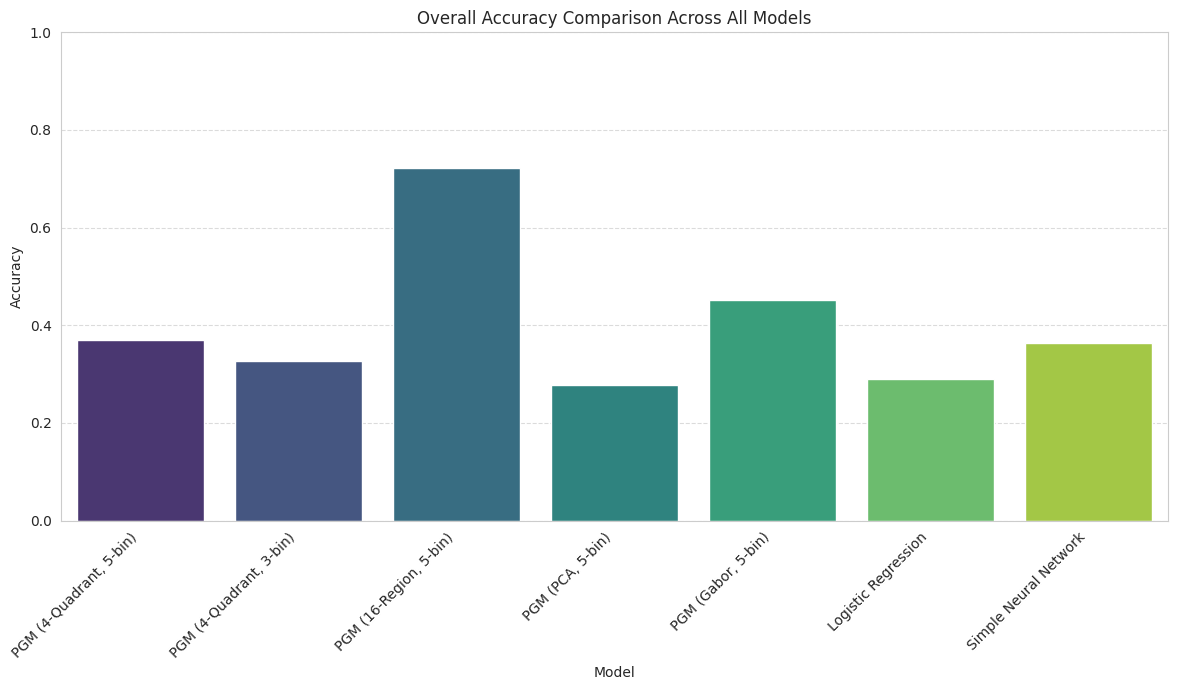

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=overall_accuracy_df, palette='viridis', legend=False)
plt.title('Overall Accuracy Comparison Across All Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Reasoning**:
The next instruction is to visualize the class-wise AUC scores of all models. I need to melt the `class_wise_auc_df` for easier plotting with Seaborn and then create a bar plot.



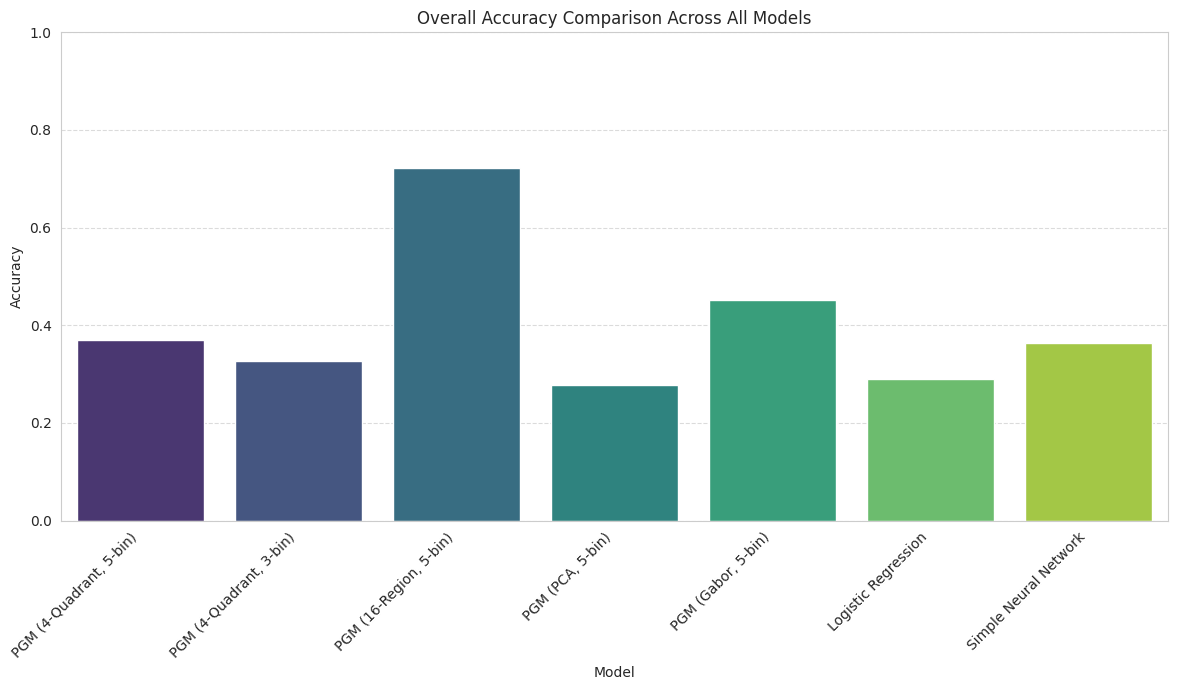

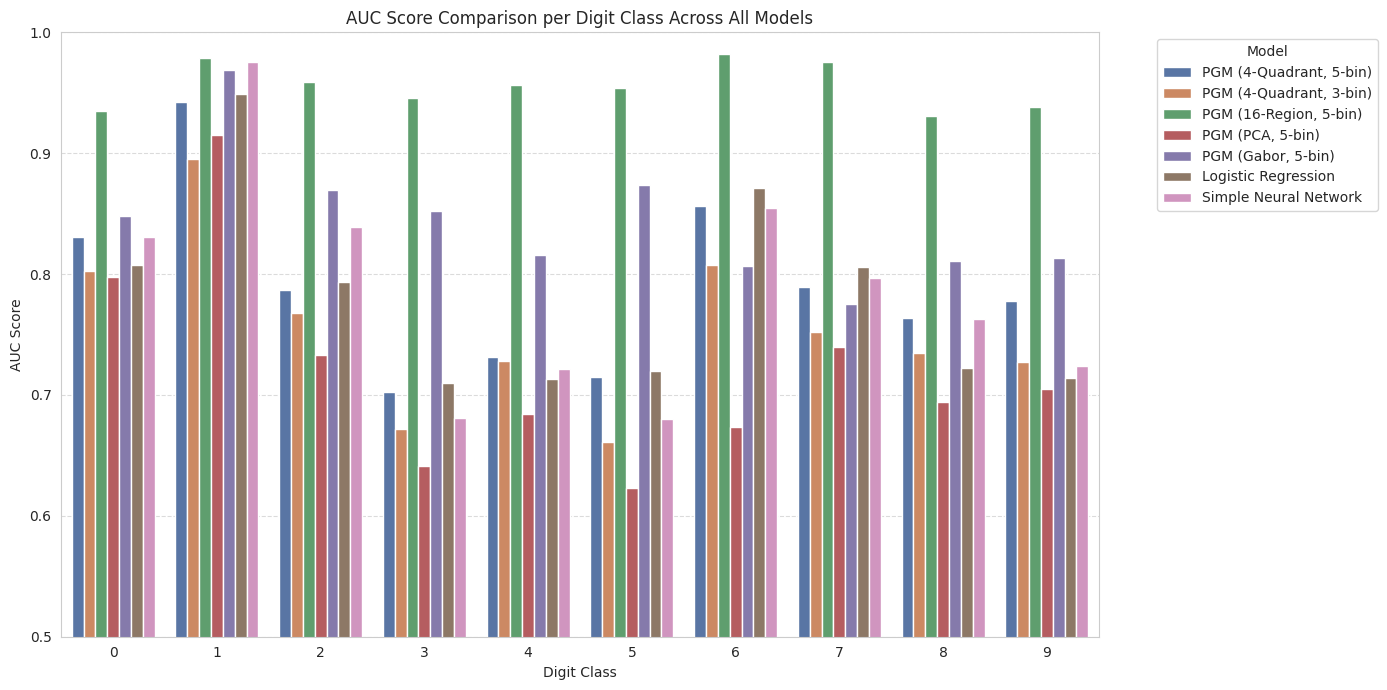

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=overall_accuracy_df, palette='viridis', legend=False)
plt.title('Overall Accuracy Comparison Across All Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Melt the class_wise_auc_df for easier plotting
auc_melted_df = class_wise_auc_df.melt(id_vars='Digit Class', var_name='Model', value_name='AUC')

# Plot AUC comparison per digit class
plt.figure(figsize=(14, 7))
sns.barplot(x='Digit Class', y='AUC', hue='Model', data=auc_melted_df, palette='deep')
plt.title('AUC Score Comparison per Digit Class Across All Models')
plt.ylabel('AUC Score')
plt.xlabel('Digit Class')
plt.ylim(0.5, 1) # AUC scores typically range from 0.5 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()